In [1]:
!pwd

/tscc/lustre/restricted/alexandrov-ddn/users/ymadakamutil/DeepHRD_full/ImmuneHRD_data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
rnaseq_df = pd.read_csv('rna_seq/tcga.brca.rnaseq.unstranded.fpkm.counts.matrix.txt', sep='\t', index_col=0)
# rnaseq_df = pd.read_csv("data/Deconvo2.csv", sep = ',', index_col=0)
print(f"Initial samples in RNA-seq data (n = {len(rnaseq_df.index)})")
# Load the HRD score data
hrd_df = pd.read_csv('HRDscores/hrd_annot.csv')
print(f"\n\nInitial samples with BRCA and HRD annotations (n = {len(hrd_df.index)})")

Initial samples in RNA-seq data (n = 1231)


Initial samples with BRCA and HRD annotations (n = 857)


In [4]:
rnaseq_df.shape

(1231, 60663)

In [5]:
hrd_df_filt = hrd_df[(hrd_df['event.BRCA1'] != '1') & (hrd_df['event.BRCA2'] != 'Bi-allelic-undetermined') & (hrd_df['event.PALB2'] != '2')]
hrd_df_filt.set_index('sample', inplace=True)
print(f"\n\n Number of samples after filtering ambig BRCA annot (n = {len(hrd_df_filt.index)})")



 Number of samples after filtering ambig BRCA annot (n = 857)


In [6]:
rnaseq_df.head()

,Case ID,Sample ID,Sample Type,ENSG00000000003.15|TSPAN6|protein_coding,ENSG00000000005.6|TNMD|protein_coding,ENSG00000000419.13|DPM1|protein_coding,ENSG00000000457.14|SCYL3|protein_coding,ENSG00000000460.17|C1orf112|protein_coding,ENSG00000000938.13|FGR|protein_coding,ENSG00000000971.16|CFH|protein_coding,...,ENSG00000288661.1|AL451106.1|protein_coding,ENSG00000288662.1|AC092910.4|lncRNA,ENSG00000288663.1|AC073611.1|lncRNA,ENSG00000288665.1|AC136977.1|lncRNA,ENSG00000288667.1|AC078856.1|lncRNA,ENSG00000288669.1|AC008763.4|protein_coding,ENSG00000288670.1|AL592295.6|lncRNA,ENSG00000288671.1|AC006486.3|protein_coding,ENSG00000288674.1|AL391628.1|protein_coding,ENSG00000288675.1|AP006621.6|protein_coding
0,TCGA-E9-A1RH,TCGA-E9-A1RH-01A,Primary Tumor,1.0276,0.0000,74.2709,1.3816,1.6749,1.4166,5.2410,...,0.0,0.0000,0.0177,0.0,0.0000,0.0000,1.8073,0.0,0.0000,0.1285
1,TCGA-C8-A26W,TCGA-C8-A26W-01A,Primary Tumor,13.2684,0.1250,37.9298,3.7360,3.1045,2.4799,7.4851,...,0.0,0.0000,0.0847,0.0,0.0000,0.0036,3.4634,0.0,0.0074,0.3801
2,TCGA-E9-A1RH,TCGA-E9-A1RH-11A,Solid Tissue Normal,12.8007,8.4777,21.6363,2.4554,0.5852,2.7533,27.4655,...,0.0,0.2708,0.0456,0.0,0.2664,0.0041,5.8816,0.0,0.0372,0.1064
3,TCGA-AO-A0JJ,TCGA-AO-A0JJ-01A,Primary Tumor,14.8681,2.2172,27.8838,4.3170,1.7847,3.7167,9.6630,...,0.0,0.0000,0.0261,0.0,0.0000,0.0000,3.2723,0.0,0.0058,0.2546
4,TCGA-BH-A0HO,TCGA-BH-A0HO-01A,Primary Tumor,0.8430,0.0798,22.1105,3.9971,0.9805,2.4742,3.8185,...,0.0,0.0000,0.0253,0.0,0.0000,0.0000,3.1233,0.0,0.0041,0.4599


In [7]:
hrd_df

,sample,Unnamed: 0,HRD,Telomeric AI,LST,HRD-sum,BRCA1_somatic_null,BRCA1_germ_bi_allelic,BRCA1_germ_mono_allelic,BRCA1_deletion,...,event.RAD51C,event.PALB2,event.All Events,event.PAM50,event.TNBC,HRD_status_base,HRD_adjust,soft prob,HRD_status,BRCA_status
0,TCGA-A1-A0SB,0,0,0,0,0,0,0,0.0,0,...,0,0,0,NaN,0,HR,HRP,0.00000,0,0
1,TCGA-A1-A0SD,1,10,10,7,27,0,0,0.0,0,...,0,0,0,LumA,0,HR,HRD ambiguous,0.66125,0,0
2,TCGA-A1-A0SE,2,6,6,1,13,0,0,0.0,0,...,0,0,0,LumA,0,HR,HRP ambiguous,0.00000,0,0
3,TCGA-A1-A0SF,3,7,11,8,26,0,0,0.0,0,...,0,0,0,LumA,0,HR,HRD ambiguous,0.72000,0,0
4,TCGA-A1-A0SG,4,3,2,4,9,0,0,0.0,0,...,0,0,0,LumA,0,HR,HRP,0.00000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,TCGA-OL-A6VR,852,4,4,5,13,0,0,0.0,NaN,...,0,0,0,LumA,0,HR,HRP ambiguous,0.00000,0,0
853,TCGA-PE-A5DC,853,13,20,16,49,0,0,0.0,0,...,0,0,YES,LumA,0,HRD,HRD ambiguous,0.00125,1,0
854,TCGA-PE-A5DD,854,7,6,9,22,0,0,0.0,0,...,0,0,0,LumA,0,HR,HRP ambiguous,0.02000,0,0
855,TCGA-PE-A5DE,855,6,15,11,32,0,0,0.0,0,...,0,0,0,LumA,0,HR,HRD ambiguous,0.40500,0,0


In [8]:
#filt protein coding only
columns_to_keep = ['Case ID', 'Sample ID', 'Sample Type']
# columns_to_keep =[]
gene_columns = [col for col in rnaseq_df.columns if col not in columns_to_keep]
protein_coding_cols = [col for col in gene_columns if 'protein_coding' in col]
final_columns = columns_to_keep + protein_coding_cols
pcg_rnaseq_df_filtered = rnaseq_df[final_columns]

#filt only primary tumor
pcg_rnaseq_df_filtered = pcg_rnaseq_df_filtered[pcg_rnaseq_df_filtered['Sample Type'] == 'Primary Tumor']
print(pcg_rnaseq_df_filtered.shape)
#Slicing gene names
# split 0 for enseble ID, 1 for gene ID

sliced_cols = [col.split('|')[1] for col in pcg_rnaseq_df_filtered.columns[3:]]

pcg_rnaseq_df_filtered.columns = columns_to_keep+sliced_cols
pcg_rnaseq_df_filtered.set_index('Case ID', inplace=True)

(1111, 19965)


In [9]:
pcg_rnaseq_df_filtered.head()

,Sample ID,Sample Type,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,...,ACTL10,AC119733.1,AC020765.6,AC010980.1,AC004233.4,AL451106.1,AC008763.4,AC006486.3,AL391628.1,AP006621.6
Case ID,,,,,,,,,,,,,,,,,,,,,
TCGA-E9-A1RH,TCGA-E9-A1RH-01A,Primary Tumor,1.0276,0.0000,74.2709,1.3816,1.6749,1.4166,5.2410,8.4782,...,0.0,0.0,0.0037,0.0582,0.0000,0.0,0.0000,0.0,0.0000,0.1285
TCGA-C8-A26W,TCGA-C8-A26W-01A,Primary Tumor,13.2684,0.1250,37.9298,3.7360,3.1045,2.4799,7.4851,30.4546,...,0.0,0.0,0.0000,0.0191,0.0195,0.0,0.0036,0.0,0.0074,0.3801
TCGA-AO-A0JJ,TCGA-AO-A0JJ-01A,Primary Tumor,14.8681,2.2172,27.8838,4.3170,1.7847,3.7167,9.6630,16.7889,...,0.0,0.0,0.0000,0.0313,0.0512,0.0,0.0000,0.0,0.0058,0.2546
TCGA-BH-A0HO,TCGA-BH-A0HO-01A,Primary Tumor,0.8430,0.0798,22.1105,3.9971,0.9805,2.4742,3.8185,12.5473,...,0.0,0.0,0.0034,0.0088,0.0000,0.0,0.0000,0.0,0.0041,0.4599
TCGA-BH-A18F,TCGA-BH-A18F-01A,Primary Tumor,10.1027,8.2031,29.6694,5.2897,3.2049,2.8792,10.0696,9.2545,...,0.0,0.0,0.0055,0.2087,0.0000,0.0,0.0000,0.0,0.0067,0.6483


In [10]:
#idenfity the common samples

# Extract sample IDs from each dataframe
rnaseq_samples = set(pcg_rnaseq_df_filtered.index)
metadata_samples = set(hrd_df_filt.index)

# Find the intersection of all sample IDs
common_samples = rnaseq_samples.intersection(metadata_samples)

# Print the number of common samples
print("\nNumber of common samples:", len(common_samples))


Number of common samples: 857


In [11]:
# Drop samples that are not common in all three dataframes
gene_expression = pcg_rnaseq_df_filtered[pcg_rnaseq_df_filtered.index.isin(common_samples)]
labels = hrd_df_filt[hrd_df_filt.index.isin(common_samples)]

# Print the shapes of the new dataframes
print("pcg_rnaseq_df_filtered:", gene_expression.shape)
print("metadata_common:", labels.shape)

pcg_rnaseq_df_filtered: (857, 19964)
metadata_common: (857, 43)


In [12]:
# Soft label method
def softLabel(x, median, HRD_thresh, HRP_thresh):
    adjustment = 2 * ((((HRD_thresh - x) / (HRD_thresh - HRP_thresh))-0.5) ** 2)+0.5
    if x < HRP_thresh:
        return 0
    elif x >= HRD_thresh:
        return 1
    elif median <= x < HRD_thresh:
        return min(adjustment, 1)
    elif HRP_thresh <= x < median:
        return max(1 - adjustment,0)

In [13]:
softLabel_metadata = labels.copy()
softLabel_metadata['HRD_status_base'] = softLabel_metadata['HRD-sum'].apply(lambda x: 'HRD' if x >= 42 else 'HR')
total_median = softLabel_metadata['HRD-sum'].median()
softLabel_metadata['HRD_adjust'] = ['HRD' if x >= 50 else 'HRP' if x <= 10 else 'HRD ambiguous' if total_median <= x <50 else 'HRP ambiguous' if 10 <= x < total_median else 'None' for x in softLabel_metadata['HRD-sum']]
softLabel_metadata['soft prob'] = softLabel_metadata['HRD-sum'].apply(lambda x: softLabel(x, 30, 50, 10))
softLabel_metadata = softLabel_metadata.rename_axis('Case ID', axis='index')

In [14]:
softLabel_metadata['HRD_status_base'].value_counts()

HRD_status_base
HR     652
HRD    205
Name: count, dtype: int64

In [15]:
vae_genes_path = "../../microbiome_mechinterp/q2_mechinterp/examples/tcga_brc_vae_out/gene_importance.csv"
vae_genes_df = pd.read_csv(vae_genes_path)
vae_genes_df.head()

,Feature,Importance,Input_Weight_Importance
0,BTN1A1,6.813919,6.813919
1,CSN1S1,6.443826,6.443826
2,CSN2,6.296290,6.296290
3,CNMD,6.107017,6.107017
4,C1S,6.047998,6.047998


In [16]:
gene_expression_int = gene_expression.iloc[:,2:].astype(int)

softLabel_metadata = softLabel_metadata.sort_index()
gene_expression_int = gene_expression_int.sort_index()

print(gene_expression_int.index.equals(softLabel_metadata.index))

True


In [17]:
vae_genes = list(vae_genes_df['Feature'])
print(len(vae_genes))

1773


In [18]:
mt_genes = [gene for gene in vae_genes if gene.startswith('MT-')]
print(mt_genes)
print(f"Total MT genes: {len(mt_genes)}")

['MT-CO1', 'MT-ND5', 'MT-ND4L', 'MT-ATP8', 'MT-ND4', 'MT-ATP6', 'MT-CO2', 'MT-ND6', 'MT-CYB', 'MT-CO3', 'MT-ND1', 'MT-ND3', 'MT-ND2']
Total MT genes: 13


In [19]:
vae_genes_filt = [gene for gene in vae_genes if gene not in mt_genes]
print(len(vae_genes_filt))

1760


In [20]:
common_vae_genes = gene_expression_int.loc[:, gene_expression_int.columns.isin(vae_genes_filt)]
common_vae_genes

,DPM1,LAP3,CD99,CD99,LASP1,SLC7A2,ARF5,POLDIP2,FKBP4,NDUFAB1,...,MRPS21,CCL5,CD24,PIP4K2B,H2AC8,MARCKS,PSMB3,CISD3,H3C10,MRPL45
Case ID,,,,,,,,,,,,,,,,,,,,,
TCGA-A1-A0SB,21,23,10,0,27,1,51,43,21,17,...,31,1,270,28,0,85,41,2,0,39
TCGA-A1-A0SD,38,47,30,0,47,293,51,42,64,30,...,52,11,578,22,4,70,71,12,5,23
TCGA-A1-A0SE,21,32,39,0,83,95,69,48,125,39,...,60,19,160,23,0,30,65,12,6,29
TCGA-A1-A0SF,28,36,32,0,72,23,96,51,78,34,...,52,59,325,19,0,38,86,12,0,29
TCGA-A1-A0SG,26,31,31,0,33,1,55,57,78,53,...,37,10,1004,15,28,26,85,15,19,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-OL-A6VR,28,34,23,0,33,50,69,54,93,37,...,64,4,129,18,11,32,103,21,4,37
TCGA-PE-A5DC,26,29,32,0,49,21,95,52,116,42,...,63,22,173,19,62,30,132,10,92,40
TCGA-PE-A5DD,24,27,62,0,44,1,98,34,72,31,...,31,37,340,14,7,19,91,14,1,10


In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt

def preprocess_data(X, y):
    """
    Preprocess data for classification with label encoding and scaling.
    Parameters:
    X: Feature matrix (RNA-seq data)
    y: Target vector (HRD status)
    """
    # Encode categorical labels
    le = LabelEncoder()
    y = le.fit_transform(y)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test

def train_evaluate_elastic_net(X_train, X_test, y_train, y_test):
    """
    Train and evaluate Elastic Net model for HRD classification.
    """
    # Initialize and train model
    model = LogisticRegression(penalty='elasticnet', solver='saga', 
                             l1_ratio=0.5, max_iter=1000)
    model.fit(X_train, y_train)
    
    # Get predictions
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'Elastic Net (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for HRD Classification')
    plt.legend(loc="lower right")
    plt.show()
    
    return {
        'AUC': roc_auc,
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
        'Classification Report': classification_report(y_test, y_pred),
        'Model': model
    }

def get_top_features(model, feature_names, n_features):
    """
    Extract top features based on absolute coefficient values.
    
    Parameters:
    model: Trained model object
    feature_names: List/array of feature names
    n_features: Number of top features to return
    
    Returns:
    List of top feature names
    """
    coefficients = model.coef_[0]  # Get coefficients from the model
    absolute_coefficients = np.abs(coefficients)
    top_indices = np.argsort(absolute_coefficients)[-n_features:]
    top_features = feature_names[top_indices]
    return list(top_features)

def main(gene_df, hrd_status, n_features):
    """
    Main function to run HRD classification using Elastic Net.
    Parameters:
    gene_df: DataFrame with gene expression data
    hrd_status: Series with HRD status labels
    """
    # Preprocess data
    X_train, X_test, y_train, y_test = preprocess_data(
        gene_df, hrd_status
    )
    
    # Train and evaluate model
    results = train_evaluate_elastic_net(X_train, X_test, y_train, y_test)
    
    # Print results
    print("\nElastic Net Classification Results:")
    print(f"AUC: {results['AUC']:.3f}")
    print("\nClassification Report:")
    print(results['Classification Report'])
    print("\nConfusion Matrix:")
    print(results['Confusion Matrix'])
    
    # Get top features
    top_features = get_top_features(results['Model'], gene_df.columns, n_features)
    print("\nTop " + str(n_features) + " predictive genes:")
    print(top_features)
    
    return results, top_features


/tscc/nfs/home/ymadakamutil/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/tscc/nfs/home/ymadakamutil/.local/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


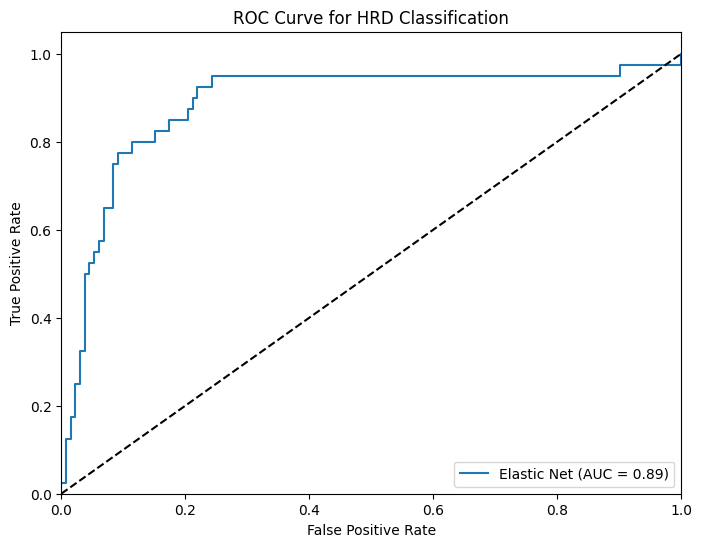


Elastic Net Classification Results:
AUC: 0.888

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       132
           1       0.74      0.65      0.69        40

    accuracy                           0.87       172
   macro avg       0.82      0.79      0.80       172
weighted avg       0.86      0.87      0.86       172


Confusion Matrix:
[[123   9]
 [ 14  26]]

Top 500 predictive genes:
['RPS20', 'PGRMC1', 'NECTIN2', 'GSTM3', 'CES1', 'DPM1', 'PLP2', 'GFUS', 'KCTD3', 'SSR2', 'NCAPD2', 'GJA1', 'CIAO2B', 'UGT2B11', 'NOLC1', 'TAT', 'KDELR2', 'DSG3', 'AHCYL1', 'WARS1', 'SUMO3', 'GAPDH', 'CD99', 'BEX3', 'MUC5B', 'RPL36AL', 'CLU', 'FMOD', 'CXCL11', 'NFE2L1', 'AURKAIP1', 'DUSP4', 'PLVAP', 'PLD3', 'UBA1', 'CCDC47', 'RPS27A', 'PRKDC', 'COL11A2', 'ECEL1', 'ATP6V0B', 'IFITM1', 'CXCL16', 'FGD3', 'SQLE', 'MKNK2', 'BCAS2', 'GOLPH3', 'EI24', 'VEGFB', 'MRPL47', 'CITED2', 'TXN2', 'IDH2', 'PSMD3', 'JUN', 'OST4', 'TSPAN1', 'SCGN

In [22]:
results_de, top_genes_de =  main(common_vae_genes, softLabel_metadata['HRD_status_base'], n_features=500)

In [23]:
enet_model = results_de['Model']

In [24]:
results_de

{'AUC': 0.887689393939394,
 'Confusion Matrix': array([[123,   9],
        [ 14,  26]]),
 'Classification Report': '              precision    recall  f1-score   support\n\n           0       0.90      0.93      0.91       132\n           1       0.74      0.65      0.69        40\n\n    accuracy                           0.87       172\n   macro avg       0.82      0.79      0.80       172\nweighted avg       0.86      0.87      0.86       172\n',
 'Model': LogisticRegression(l1_ratio=0.5, max_iter=1000, penalty='elasticnet',
                    solver='saga')}

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             accuracy_score, mean_squared_error, r2_score)
from sklearn.model_selection import ParameterGrid
import os

OUT_DIR = 'softHRD_figs'
os.makedirs(OUT_DIR, exist_ok=True)


# ── Preprocessing ─────────────────────────────────────────────────────────────

def preprocess_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


# ── Threshold selection ───────────────────────────────────────────────────────

CANDIDATE_THRESHOLDS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

def find_optimal_threshold(y_true, y_pred_proba):
    y_true       = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba)
    records = []
    for t in CANDIDATE_THRESHOLDS:
        y_pred = (y_pred_proba >= t).astype(int)
        f1     = f1_score(y_true, y_pred, zero_division=0)
        prec   = precision_score(y_true, y_pred, zero_division=0)
        rec    = recall_score(y_true, y_pred, zero_division=0)
        acc    = accuracy_score(y_true, y_pred)
        denom  = (1/f1 + 1/prec + 1/rec) if (f1 > 0 and prec > 0 and rec > 0) else np.inf
        balance = 3 / denom if denom != np.inf else 0.0
        records.append({'threshold': t, 'f1': f1, 'precision': prec,
                        'recall': rec, 'accuracy': acc, 'balance_score': balance})
    df       = pd.DataFrame(records)
    best_row = df.loc[df['balance_score'].idxmax()]
    return best_row['threshold'], df


# ── Point-estimate metrics ────────────────────────────────────────────────────

def compute_metrics(y_true, y_pred_proba, threshold):
    y_true = np.array(y_true)
    y_pred = (y_pred_proba >= threshold).astype(int)
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc     = auc(fpr, tpr)
    cm          = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'roc_auc':     roc_auc,
        'f1':          f1_score(y_true, y_pred, zero_division=0),
        'precision':   precision_score(y_true, y_pred, zero_division=0),
        'recall':      recall_score(y_true, y_pred, zero_division=0),
        'accuracy':    accuracy_score(y_true, y_pred),
        'sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'fpr': fpr, 'tpr': tpr,
        'confusion_matrix': cm,
        'threshold': threshold,
    }


# ── Non-zero model coefficients ───────────────────────────────────────────────

def get_nonzero_coefficients(model, feature_names, top_n=None):
    coefs   = pd.DataFrame({'feature': feature_names, 'coefficient': model.coef_})
    nonzero = coefs[coefs['coefficient'] != 0].copy()
    nonzero['abs_coef'] = nonzero['coefficient'].abs()
    nonzero = nonzero.sort_values('abs_coef', ascending=False).drop(columns='abs_coef')
    if top_n:
        nonzero = nonzero.head(top_n)
    return nonzero.reset_index(drop=True)


# ── Build test predictions DataFrame with sample IDs ─────────────────────────

def build_test_predictions(model, X_test, y_test, threshold):
    pred_linear = model.predict(X_test)
    pred_binary = (pred_linear >= threshold).astype(int)

    test_preds = pd.DataFrame({
        'bcr_patient_barcode': y_test.index,
        'pred_linear':         pred_linear,
        'pred_binary':         pred_binary,
        'HRD_predicted':       np.where(pred_binary == 1, 'HRD', 'HR'),
        'true_soft_prob':      y_test.values,
    }).set_index('bcr_patient_barcode')

    print(f"\nTest set predictions — {len(test_preds)} samples")
    print(test_preds['HRD_predicted'].value_counts().to_string())

    return test_preds


# ── Elastic Net grid search ───────────────────────────────────────────────────

def train_elastic_net(X_train, X_test, y_train, y_test,
                      alphas, l1_ratios, feature_names):
    best_model, best_mse, best_params = None, float('inf'), {}

    for params in ParameterGrid({'alpha': alphas, 'l1_ratio': l1_ratios}):
        model = ElasticNet(alpha=params['alpha'], l1_ratio=params['l1_ratio'],
                           max_iter=1000, random_state=42)
        model.fit(X_train, y_train)
        mse = mean_squared_error(y_test, model.predict(X_test))
        if mse < best_mse:
            best_mse    = mse
            best_model  = model
            best_params = params

    y_pred = best_model.predict(X_test)
    mse    = mean_squared_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    print(f"\nBest Elastic Net params : {best_params}")
    print(f"Test MSE : {mse:.4f}  |  R² : {r2:.4f}")

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal')
    ax.set_xlabel('Actual HRD probability',    fontsize=12, fontweight='bold')
    ax.set_ylabel('Predicted HRD probability', fontsize=12, fontweight='bold')
    ax.set_title('Elastic Net: Predicted vs Actual', fontsize=13, fontweight='bold')
    ax.text(0.05, 0.95,
            f"MSE = {mse:.4f}\n$R^2$ = {r2:.4f}",
            transform=ax.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='grey', linewidth=0.8, alpha=0.9))
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, 'fig_elasticnet_predicted_vs_actual.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    coef_df = get_nonzero_coefficients(best_model, feature_names)
    print(f"\nNon-zero coefficients ({len(coef_df)} features):")
    print(coef_df.to_string(index=True))

    return best_model, best_params, coef_df, y_pred


# ── Plots ─────────────────────────────────────────────────────────────────────

def plot_threshold_comparison(threshold_df, best_threshold):
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(threshold_df))
    w = 0.25
    bars_f1   = ax.bar(x - w, threshold_df['f1'],       w, label='F1',        color='#9966CC', alpha=0.85, edgecolor='black')
    bars_prec = ax.bar(x,     threshold_df['precision'], w, label='Precision', color='#4472C4', alpha=0.85, edgecolor='black')
    bars_rec  = ax.bar(x + w, threshold_df['recall'],    w, label='Recall',    color='#ED7D31', alpha=0.85, edgecolor='black')
    best_idx  = threshold_df[threshold_df['threshold'] == best_threshold].index[0]
    for bar_group in [bars_f1, bars_prec, bars_rec]:
        bar_group[best_idx].set_edgecolor('#70AD47')
        bar_group[best_idx].set_linewidth(3)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{t:.1f}" for t in threshold_df['threshold']], fontsize=11)
    ax.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax.set_ylabel('Score',     fontsize=12, fontweight='bold')
    ax.set_title(f'F1 / Precision / Recall across thresholds  (★ optimal = {best_threshold})',
                 fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.15); ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axvline(best_idx, color='#70AD47', linestyle='--', linewidth=1.5, alpha=0.6)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, 'fig_threshold_comparison.png'),
                dpi=300, bbox_inches='tight')
    plt.show()


def plot_roc(metrics):
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot(metrics['fpr'], metrics['tpr'], 'b-', lw=2.5,
            label=f"AUC = {metrics['roc_auc']:.3f}")
    ax.fill_between(metrics['fpr'], metrics['tpr'], alpha=0.15)
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
    ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Positive Rate',  fontsize=12, fontweight='bold')
    ax.set_title(f'ROC Curve  (threshold = {metrics["threshold"]:.1f})',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, 'fig_roc_curve.png'),
                dpi=300, bbox_inches='tight')
    plt.show()


def plot_confusion(metrics):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                ax=ax, annot_kws={'fontsize': 14, 'fontweight': 'bold'})
    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_ylabel('True',      fontsize=12, fontweight='bold')
    ax.set_title(f'Confusion Matrix  (threshold = {metrics["threshold"]:.1f})',
                 fontsize=13, fontweight='bold')
    ax.set_xticklabels(['HR (0)', 'HRD (1)'], fontsize=10)
    ax.set_yticklabels(['HR (0)', 'HRD (1)'], fontsize=10, rotation=0)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, 'fig_confusion_matrix.png'),
                dpi=300, bbox_inches='tight')
    plt.show()


def plot_top_coefficients(coef_df, top_n=20):
    df     = coef_df.head(top_n).copy()
    colors = ['#E05C5C' if c > 0 else '#5B8DB8' for c in df['coefficient']]
    fig, ax = plt.subplots(figsize=(8, max(4, len(df) * 0.35)))
    ax.barh(df['feature'][::-1], df['coefficient'][::-1],
            color=colors[::-1], edgecolor='black', linewidth=0.6)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('Coefficient', fontsize=12, fontweight='bold')
    ax.set_title(f'Top {len(df)} Non-Zero Elastic Net Coefficients',
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, 'fig_top_coefficients.png'),
                dpi=300, bbox_inches='tight')
    plt.show()


def print_summary(metrics, best_threshold, threshold_df):
    print("\n" + "="*60)
    print("CLASSIFICATION RESULTS")
    print("="*60)
    print(threshold_df[['threshold','f1','precision','recall','balance_score']]
          .to_string(index=False, float_format='{:.4f}'.format))
    print(f"\n★  Optimal threshold (max harmonic balance): {best_threshold:.1f}")
    print("\n" + "-"*60)
    print(f"  ROC AUC     : {metrics['roc_auc']:.4f}")
    print(f"  F1 Score    : {metrics['f1']:.4f}")
    print(f"  Precision   : {metrics['precision']:.4f}")
    print(f"  Recall      : {metrics['recall']:.4f}")
    print(f"  Accuracy    : {metrics['accuracy']:.4f}")
    print(f"  Sensitivity : {metrics['sensitivity']:.4f}")
    print(f"  Specificity : {metrics['specificity']:.4f}")
    print("="*60 + "\n")


# ── Main ──────────────────────────────────────────────────────────────────────

def main(y_true_binary=None, optimization_metric='f1'):

    feature_names = list(common_vae_genes.columns)

    X_train, X_test, y_train, y_test, scaler = preprocess_data(
        common_vae_genes, softLabel_metadata['soft prob']
    )

    alphas    = [0.01, 0.1, 0.25, 0.5, 1.0]
    l1_ratios = [0.5]

    best_model, best_params, coef_df, y_pred_reg = train_elastic_net(
        X_train, X_test, y_train, y_test, alphas, l1_ratios, feature_names
    )
    plot_top_coefficients(coef_df, top_n=20)

    metrics    = None
    test_preds = None

    if y_true_binary is not None:
        y_pred_proba = best_model.predict(X_test)

        if hasattr(y_test, 'index'):
            if hasattr(y_true_binary, 'loc'):
                y_test_binary = y_true_binary.loc[y_test.index].values
            else:
                y_test_binary = pd.Series(
                    y_true_binary, index=softLabel_metadata.index
                ).loc[y_test.index].values
        else:
            y_test_binary = np.array(y_true_binary)

        best_threshold, threshold_df = find_optimal_threshold(y_test_binary, y_pred_proba)
        metrics = compute_metrics(y_test_binary, y_pred_proba, best_threshold)

        print_summary(metrics, best_threshold, threshold_df)
        plot_threshold_comparison(threshold_df, best_threshold)
        plot_roc(metrics)
        plot_confusion(metrics)

        test_preds = build_test_predictions(best_model, X_test, y_test, best_threshold)

    print(f"\nAll figures saved to: {os.path.abspath(OUT_DIR)}")
    return best_model, best_params, coef_df, metrics, test_preds


Best Elastic Net params : {'alpha': 0.01, 'l1_ratio': 0.5}
Test MSE : 0.0408  |  R² : 0.6781


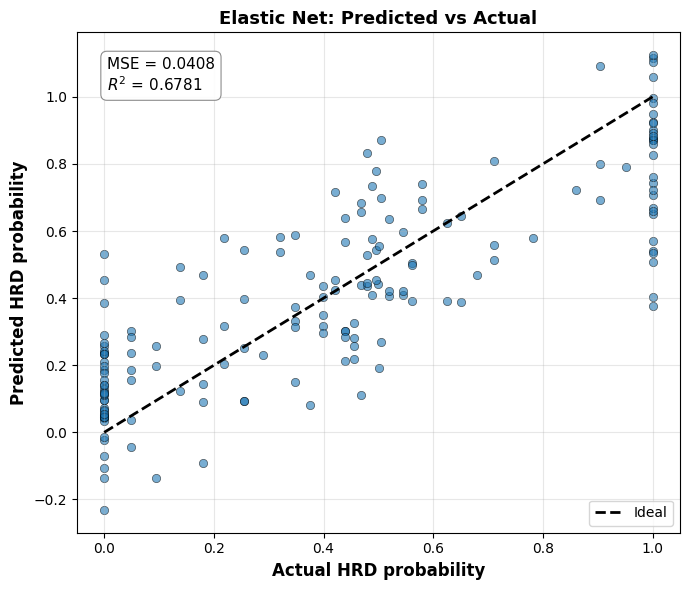


Non-zero coefficients (286 features):
      feature  coefficient
0      ALYREF     0.032226
1       SUMO1     0.028182
2        TPT1    -0.023134
3        MYL9     0.020197
4       PSMD2     0.016656
5       CD151    -0.016467
6      TIMM10     0.016375
7    TP53INP1    -0.016355
8        IDH1     0.016305
9        RPL7    -0.016119
10       BTF3    -0.015444
11      RPL32     0.015142
12       LRG1    -0.015107
13    ALDH9A1    -0.015002
14     H2BC12     0.014852
15      LAMB2    -0.014806
16     PABPC1     0.014686
17     SMIM14    -0.014646
18        MSN     0.014529
19       H1-2     0.014521
20       CPA3    -0.014505
21      MTCH1     0.014441
22      TPSB2    -0.014244
23      FGFR1     0.013857
24        GNS     0.013676
25       AREG     0.013552
26    TMEM109     0.013520
27     MRPL15    -0.013421
28    ARL6IP5    -0.013275
29       ASPN    -0.012842
30     IFITM3    -0.012707
31     UQCRC1    -0.012469
32      RPL27    -0.012423
33      CENPW     0.012339
34       RHOA   

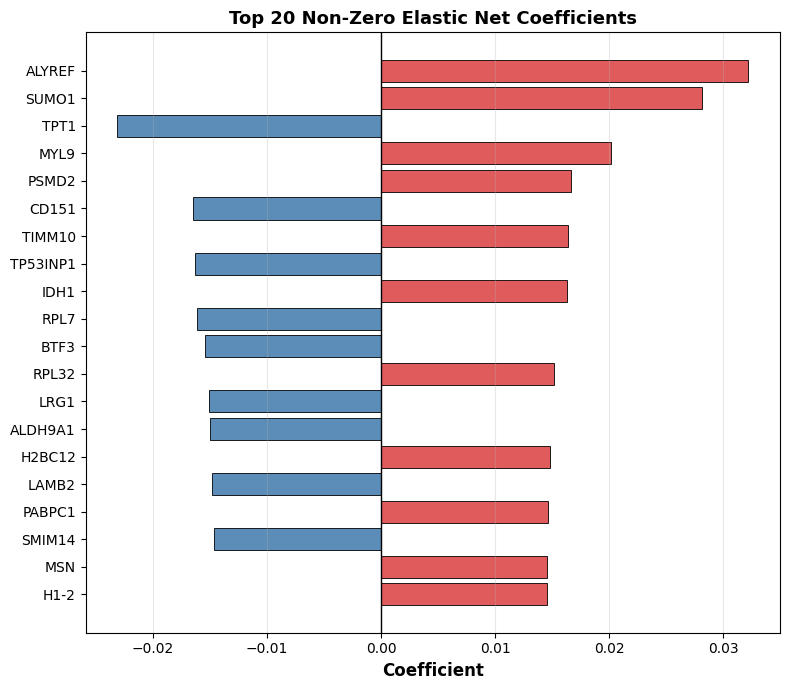


CLASSIFICATION RESULTS
 threshold     f1  precision  recall  balance_score
    0.1000 0.4348     0.2778  1.0000         0.4348
    0.2000 0.4848     0.3200  1.0000         0.4848
    0.3000 0.5594     0.3883  1.0000         0.5594
    0.4000 0.6190     0.4535  0.9750         0.6190
    0.5000 0.7048     0.5692  0.9250         0.7048
    0.6000 0.7059     0.6667  0.7500         0.7059
    0.7000 0.7222     0.8125  0.6500         0.7222
    0.8000 0.6230     0.9048  0.4750         0.6230
    0.9000 0.4314     1.0000  0.2750         0.4314
    1.0000 0.2222     1.0000  0.1250         0.2222

★  Optimal threshold (max harmonic balance): 0.7

------------------------------------------------------------
  ROC AUC     : 0.9312
  F1 Score    : 0.7222
  Precision   : 0.8125
  Recall      : 0.6500
  Accuracy    : 0.8837
  Sensitivity : 0.6500
  Specificity : 0.9545



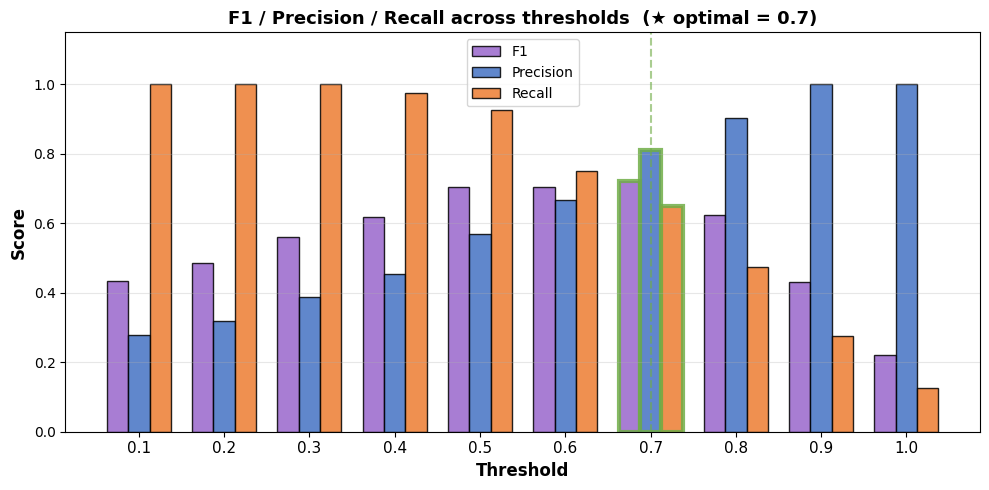

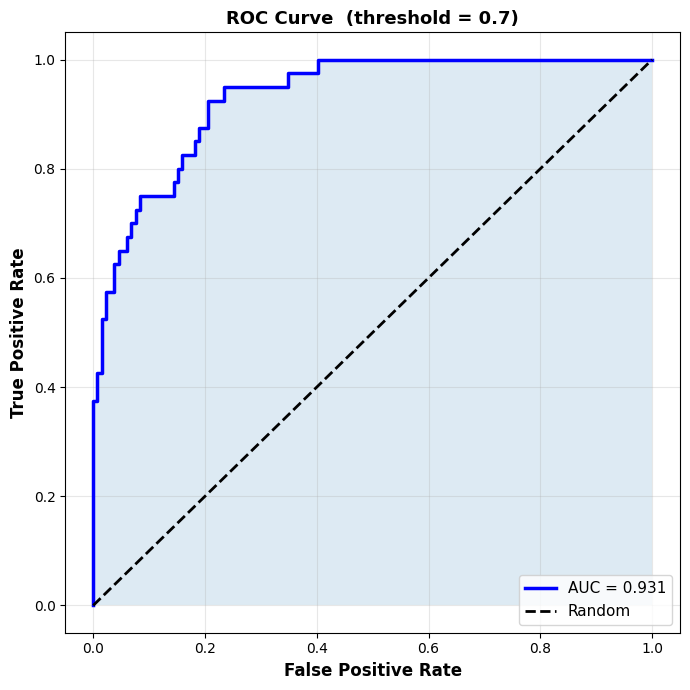

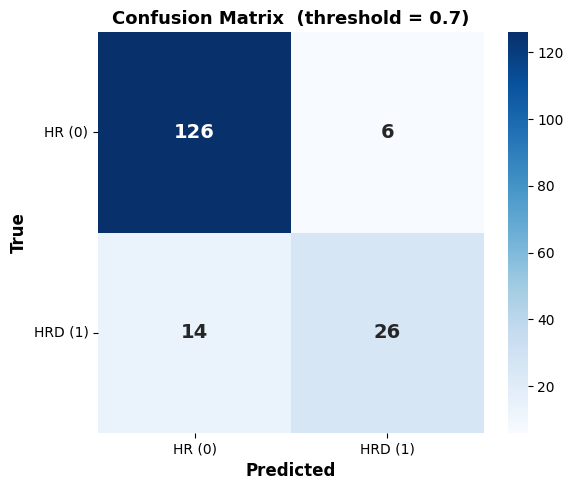


Test set predictions — 172 samples
HRD_predicted
HR     140
HRD     32

All figures saved to: /tscc/lustre/restricted/alexandrov-ddn/users/ymadakamutil/DeepHRD_full/ImmuneHRD_data/softHRD_figs


In [26]:
# ── Usage ─────────────────────────────────────────────────────────────────────
y_binary = (softLabel_metadata['HRD_status_base'] == 'HRD').astype(int)

best_model, best_params, coef_df, metrics, test_preds = main(y_true_binary=y_binary)



In [27]:
import sys
!{sys.executable} -m pip install lifelines

Defaulting to user installation because normal site-packages is not writeable


In [28]:
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

tcga_clinical = pd.read_csv('softHRD_val_data/TCGA-CDR-Table 1.csv')

def run_survival_analysis(
    test_predictions,
    clinical_df,
    duration_col,
    event_col,
    analysis_label='Overall Survival',
    time_units='Days',
    barcode_col='bcr_patient_barcode',
    age_col='age_at_initial_pathologic_diagnosis',
    stage_col='ajcc_pathologic_tumor_stage',
    penalizer=0.1        # L2 penalty — stabilises singular/near-singular matrices
):
    # ── 1. Merge ──────────────────────────────────────────────────────────────
    cols_needed = [barcode_col, duration_col, event_col, age_col, stage_col]
    merged = test_predictions.merge(
        clinical_df[cols_needed], on=barcode_col, how='inner'
    )
    merged[duration_col] = pd.to_numeric(merged[duration_col], errors='coerce')
    merged[event_col]    = pd.to_numeric(merged[event_col],    errors='coerce')
    merged[age_col]      = pd.to_numeric(merged[age_col],      errors='coerce')
    merged = merged.dropna(subset=[duration_col, event_col])
    merged = merged[merged[duration_col] > 0]

    print(f"\n{'='*60}")
    print(f"SURVIVAL ANALYSIS — {analysis_label}")
    print(f"{'='*60}")
    print(f"Samples after merge & QC : {len(merged)}")
    print(merged['HRD_predicted'].value_counts().to_string())

    # ── 2. Stage cleaning ─────────────────────────────────────────────────────
    def clean_stage(s):
        if not isinstance(s, str):
            return np.nan
        s = s.upper()
        if any(x in s for x in ['NOT AVAILABLE', 'UNKNOWN', 'NOT APPLICABLE', '[', 'X']):
            return np.nan
        if   'IV'  in s: return 'IV'
        elif 'III' in s: return 'III'
        elif 'II'  in s: return 'II'
        elif 'I'   in s: return 'I'
        return np.nan

    merged['stage_clean'] = merged[stage_col].apply(clean_stage)

    # ── 3. Diagnose separation per stage ─────────────────────────────────────
    # Flag and drop any stage level where variance conditioned on event == 0
    # (complete separation — that stage perfectly predicts outcome)
    print("\nStage variance diagnostics (conditioned on event):")
    events     = merged[event_col].astype(bool)
    keep_stages = []
    for stage in ['II', 'III', 'IV']:
        dummy = (merged['stage_clean'] == stage).astype(int)
        var_event    = dummy[events].var()
        var_no_event = dummy[~events].var()
        print(f"  Stage {stage} | var(event=1): {var_event:.4f}  "
              f"var(event=0): {var_no_event:.4f}")
        if var_event > 0.01 and var_no_event > 0.01:
            keep_stages.append(stage)
        else:
            print(f"  ⚠ Stage {stage} dropped — near-complete separation detected")

    # ── 4. Build Cox covariate matrix ─────────────────────────────────────────
    merged['HRD_binary'] = (merged['HRD_predicted'] == 'HRD').astype(int)

    # Remap stage to only keep non-separated levels; rest → NaN (excluded)
    merged['stage_filtered'] = merged['stage_clean'].where(
        merged['stage_clean'].isin(keep_stages + ['I'])  # I = reference
    )

    cox_df = merged[[duration_col, event_col, 'HRD_binary',
                     age_col, 'stage_filtered']].copy()
    cox_df = pd.get_dummies(cox_df, columns=['stage_filtered'], drop_first=True)
    cox_df.dropna(inplace=True)

    stage_dummy_cols = [c for c in cox_df.columns if c.startswith('stage_filtered_')]
    for col in stage_dummy_cols:
        cox_df[col] = cox_df[col].astype(int)

    covariates    = ['HRD_binary', age_col] + stage_dummy_cols
    n_cox_samples = len(cox_df)

    print(f"\nSamples in adjusted Cox  : {n_cox_samples}  "
          f"({len(merged) - n_cox_samples} dropped — missing/separated stage or age)")
    print(f"Covariates               : {covariates}")

    # ── 5. Univariable Cox ────────────────────────────────────────────────────
    cph_uni = CoxPHFitter(penalizer=penalizer)
    cph_uni.fit(cox_df[[duration_col, event_col, 'HRD_binary']],
                duration_col=duration_col, event_col=event_col)

    hr_uni    = np.exp(cph_uni.params_['HRD_binary'])
    ci_uni_lo = np.exp(cph_uni.confidence_intervals_.loc['HRD_binary', '95% lower-bound'])
    ci_uni_hi = np.exp(cph_uni.confidence_intervals_.loc['HRD_binary', '95% upper-bound'])
    p_uni     = cph_uni.summary.loc['HRD_binary', 'p']

    # ── 6. Multivariable Cox (penalised) ──────────────────────────────────────
    cph_adj = CoxPHFitter(penalizer=penalizer)
    cph_adj.fit(cox_df[[duration_col, event_col] + covariates],
                duration_col=duration_col, event_col=event_col)

    hr_adj    = np.exp(cph_adj.params_['HRD_binary'])
    ci_adj_lo = np.exp(cph_adj.confidence_intervals_.loc['HRD_binary', '95% lower-bound'])
    ci_adj_hi = np.exp(cph_adj.confidence_intervals_.loc['HRD_binary', '95% upper-bound'])
    p_adj     = cph_adj.summary.loc['HRD_binary', 'p']

    # ── 7. Log-rank test ──────────────────────────────────────────────────────
    hrd_mask = merged['HRD_predicted'] == 'HRD'
    hr_mask  = merged['HRD_predicted'] == 'HR'
    lr = logrank_test(
        merged.loc[hrd_mask, duration_col], merged.loc[hr_mask, duration_col],
        event_observed_A=merged.loc[hrd_mask, event_col],
        event_observed_B=merged.loc[hr_mask,  event_col]
    )

    # ── 8. Print summary ──────────────────────────────────────────────────────
    def p_label(p):
        if   p < 0.001: stars = '***'
        elif p < 0.01:  stars = '**'
        elif p < 0.05:  stars = '*'
        else:           stars = 'ns'
        return f"{stars}  (p = {p:.3e})"

    print(f"\nLog-rank            : χ² = {lr.test_statistic:.4f},  {p_label(lr.p_value)}")
    print(f"Cox unadjusted HR   : {hr_uni:.3f}  [{ci_uni_lo:.3f}–{ci_uni_hi:.3f}]  {p_label(p_uni)}")
    print(f"Cox adjusted HR     : {hr_adj:.3f}  [{ci_adj_lo:.3f}–{ci_adj_hi:.3f}]  {p_label(p_adj)}")
    print(f"  (adjusted for age + stage {keep_stages}, penalizer={penalizer})")
    print("\nFull adjusted Cox summary:")
    cph_adj.print_summary()

    # ── 9. KM plot ────────────────────────────────────────────────────────────
    color_map = {'HRD': '#E05C5C', 'HR': '#5B8DB8'}
    fig, ax   = plt.subplots(figsize=(8, 6))

    for group, color in color_map.items():
        mask = merged['HRD_predicted'] == group
        T, E = merged.loc[mask, duration_col], merged.loc[mask, event_col]
        kmf  = KaplanMeierFitter()
        kmf.fit(T, E, label=f"{group} (n={mask.sum()})")
        kmf.plot_survival_function(ax=ax, ci_show=True, color=color, linewidth=2)

    stats_text = (
        f"Log-rank: {p_label(lr.p_value)}\n"
        f"Adj. HR = {hr_adj:.3f}  [{ci_adj_lo:.3f}–{ci_adj_hi:.3f}]\n"
        f"Adj. p (age+stage): {p_label(p_adj)}"
    )
    ax.text(0.98, 0.98, stats_text,
            transform=ax.transAxes, fontsize=9,
            va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='grey', linewidth=0.8, alpha=0.95))

    ax.set_xlabel(f'Time ({time_units})', fontsize=13, fontweight='bold')
    ax.set_ylabel('Survival Probability',  fontsize=13, fontweight='bold')
    ax.set_title(f'KM — {analysis_label}  |  HRD vs HR',
                 fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=11, framealpha=0.9)
    plt.tight_layout()
    plt.show()

    return {
        'logrank':        lr,
        'cox_unadjusted': cph_uni,
        'cox_adjusted':   cph_adj,
        'HR_unadj':       hr_uni,   'CI_unadj': (ci_uni_lo, ci_uni_hi),
        'HR_adj':         hr_adj,   'CI_adj':   (ci_adj_lo, ci_adj_hi),
        'p_unadj':        p_uni,    'p_adj':    p_adj,
        'merged':         merged
    }


SURVIVAL ANALYSIS — Overall Survival
Samples after merge & QC : 171
HRD_predicted
HR     139
HRD     32

Stage variance diagnostics (conditioned on event):
  Stage II | var(event=1): 0.2632  var(event=0): 0.2473
  Stage III | var(event=1): 0.2047  var(event=0): 0.1784
  Stage IV | var(event=1): 0.0526  var(event=0): 0.0000
  ⚠ Stage IV dropped — near-complete separation detected

Samples in adjusted Cox  : 171  (0 dropped — missing/separated stage or age)
Covariates               : ['HRD_binary', 'age_at_initial_pathologic_diagnosis', 'stage_filtered_II', 'stage_filtered_III']

Log-rank            : χ² = 1.6027,  ns  (p = 2.055e-01)
Cox unadjusted HR   : 1.444  [0.639–3.261]  ns  (p = 3.767e-01)
Cox adjusted HR     : 1.640  [0.710–3.786]  ns  (p = 2.467e-01)
  (adjusted for age + stage ['II', 'III'], penalizer=0.1)

Full adjusted Cox summary:


<lifelines.CoxPHFitter: fitted with 171 total observations, 152 right-censored observations>
             duration col = 'OS.time'
                event col = 'OS'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 171
number of events observed = 19
   partial log-likelihood = -76.21
         time fit was run = 2026-05-24 19:04:25 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
HRD_binary                           0.49      1.64      0.43           -0.34            1.33                0.71                3.79
age_at_initial_pathologic_diagnosis  0.03      1.03      0.01            0.00            0.05                1.00                1.05
stage_filtered_II                    0.07      1.07      0.35           -0.62            0.75                0.54                2.13
stage_filtered_III                   0.15      1.16      0.41           -0.66            0.96                0.52                2.61

                                     cmp to    z    p  -log2(p)
covariate                                                      
HRD_binary                             0.00 1.16 0.25      2.02
age_at_initial_pathologic_diagnosis    0.00 1.98 0.05      4.40
stage_filtered_II                      0.00 0.19 0.85      0.23
stage_filtered_III                     0.00 0.36 0.72      0.48
---
Concordance = 0.68
Partial AIC = 160.42
log-likelihood ratio test = 4.77 on 4 df
-log2(p) of ll-ratio test = 1.68

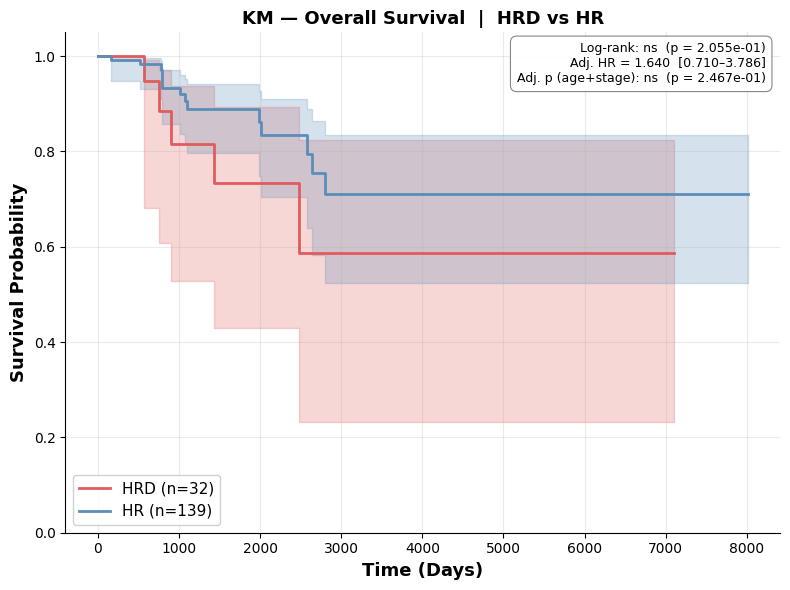


SURVIVAL ANALYSIS — Progression-Free Interval
Samples after merge & QC : 171
HRD_predicted
HR     139
HRD     32

Stage variance diagnostics (conditioned on event):
  Stage II | var(event=1): 0.2597  var(event=0): 0.2457
  Stage III | var(event=1): 0.2273  var(event=0): 0.1736
  Stage IV | var(event=1): 0.0455  var(event=0): 0.0000
  ⚠ Stage IV dropped — near-complete separation detected

Samples in adjusted Cox  : 171  (0 dropped — missing/separated stage or age)
Covariates               : ['HRD_binary', 'age_at_initial_pathologic_diagnosis', 'stage_filtered_II', 'stage_filtered_III']

Log-rank            : χ² = 0.6057,  ns  (p = 4.364e-01)
Cox unadjusted HR   : 1.259  [0.570–2.780]  ns  (p = 5.691e-01)
Cox adjusted HR     : 1.282  [0.571–2.880]  ns  (p = 5.477e-01)
  (adjusted for age + stage ['II', 'III'], penalizer=0.1)

Full adjusted Cox summary:


<lifelines.CoxPHFitter: fitted with 171 total observations, 149 right-censored observations>
             duration col = 'PFI.time'
                event col = 'PFI'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 171
number of events observed = 22
   partial log-likelihood = -95.79
         time fit was run = 2026-05-24 19:04:25 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
HRD_binary                           0.25      1.28      0.41           -0.56            1.06                0.57                2.88
age_at_initial_pathologic_diagnosis  0.00      1.00      0.01           -0.02            0.02                0.98                1.03
stage_filtered_II                   -0.10      0.90      0.34           -0.78            0.57                0.46                1.77
stage_filtered_III                   0.23      1.26      0.39           -0.54            0.99                0.58                2.70

                                     cmp to     z    p  -log2(p)
covariate                                                       
HRD_binary                             0.00  0.60 0.55      0.87
age_at_initial_pathologic_diagnosis    0.00  0.06 0.95      0.07
stage_filtered_II                      0.00 -0.30 0.76      0.39
stage_filtered_III                     0.00  0.58 0.56      0.84
---
Concordance = 0.53
Partial AIC = 199.58
log-likelihood ratio test = 0.93 on 4 df
-log2(p) of ll-ratio test = 0.12

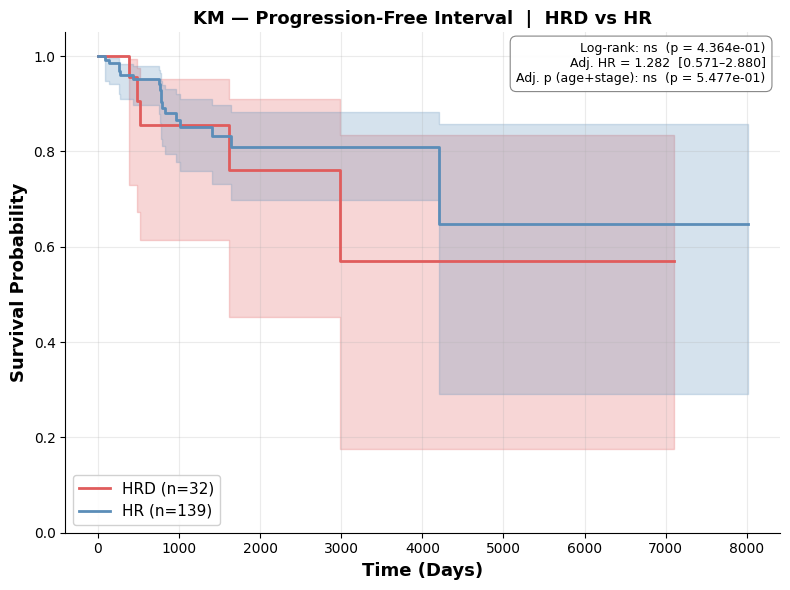


SURVIVAL ANALYSIS — Disease-Free Interval
Samples after merge & QC : 154
HRD_predicted
HR     125
HRD     29

Stage variance diagnostics (conditioned on event):
  Stage II | var(event=1): 0.2625  var(event=0): 0.2465
  Stage III | var(event=1): 0.2625  var(event=0): 0.1754
  Stage IV | var(event=1): 0.0000  var(event=0): 0.0000
  ⚠ Stage IV dropped — near-complete separation detected

Samples in adjusted Cox  : 154  (0 dropped — missing/separated stage or age)
Covariates               : ['HRD_binary', 'age_at_initial_pathologic_diagnosis', 'stage_filtered_II', 'stage_filtered_III']

Log-rank            : χ² = 2.0655,  ns  (p = 1.507e-01)
Cox unadjusted HR   : 1.547  [0.662–3.613]  ns  (p = 3.136e-01)
Cox adjusted HR     : 1.569  [0.657–3.748]  ns  (p = 3.104e-01)
  (adjusted for age + stage ['II', 'III'], penalizer=0.1)

Full adjusted Cox summary:


<lifelines.CoxPHFitter: fitted with 154 total observations, 138 right-censored observations>
             duration col = 'DFI.time'
                event col = 'DFI'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 154
number of events observed = 16
   partial log-likelihood = -69.62
         time fit was run = 2026-05-24 19:04:26 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
HRD_binary                           0.45      1.57      0.44           -0.42            1.32                0.66                3.75
age_at_initial_pathologic_diagnosis -0.00      1.00      0.01           -0.03            0.02                0.97                1.02
stage_filtered_II                   -0.08      0.92      0.39           -0.83            0.68                0.43                1.97
stage_filtered_III                   0.49      1.63      0.42           -0.34            1.32                0.71                3.73

                                     cmp to     z    p  -log2(p)
covariate                                                       
HRD_binary                             0.00  1.01 0.31      1.69
age_at_initial_pathologic_diagnosis    0.00 -0.23 0.82      0.29
stage_filtered_II                      0.00 -0.21 0.84      0.26
stage_filtered_III                     0.00  1.15 0.25      2.00
---
Concordance = 0.62
Partial AIC = 147.24
log-likelihood ratio test = 2.81 on 4 df
-log2(p) of ll-ratio test = 0.76

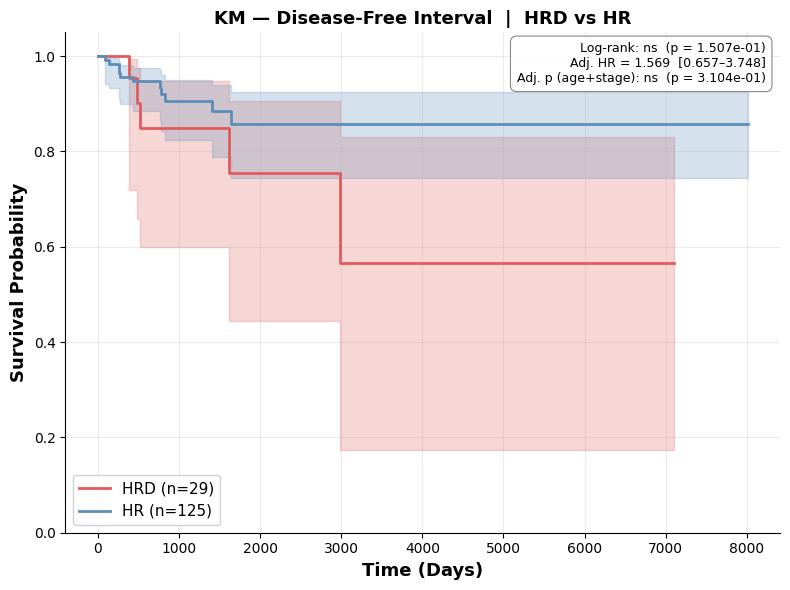


SURVIVAL ANALYSIS — Disease-Free Interval
Samples after merge & QC : 171
HRD_predicted
HR     139
HRD     32

Stage variance diagnostics (conditioned on event):
  Stage II | var(event=1): 0.2652  var(event=0): 0.2463
  Stage III | var(event=1): 0.2424  var(event=0): 0.1763
  Stage IV | var(event=1): 0.0833  var(event=0): 0.0000
  ⚠ Stage IV dropped — near-complete separation detected

Samples in adjusted Cox  : 171  (0 dropped — missing/separated stage or age)
Covariates               : ['HRD_binary', 'age_at_initial_pathologic_diagnosis', 'stage_filtered_II', 'stage_filtered_III']

Log-rank            : χ² = 0.8756,  ns  (p = 3.494e-01)
Cox unadjusted HR   : 1.309  [0.518–3.308]  ns  (p = 5.690e-01)
Cox adjusted HR     : 1.365  [0.533–3.495]  ns  (p = 5.165e-01)
  (adjusted for age + stage ['II', 'III'], penalizer=0.1)

Full adjusted Cox summary:


<lifelines.CoxPHFitter: fitted with 171 total observations, 159 right-censored observations>
             duration col = 'DSS.time'
                event col = 'DSS'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 171
number of events observed = 12
   partial log-likelihood = -50.20
         time fit was run = 2026-05-24 19:04:26 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
HRD_binary                           0.31      1.37      0.48           -0.63            1.25                0.53                3.50
age_at_initial_pathologic_diagnosis  0.01      1.01      0.01           -0.02            0.04                0.98                1.04
stage_filtered_II                   -0.14      0.87      0.39           -0.90            0.61                0.41                1.85
stage_filtered_III                   0.19      1.21      0.44           -0.67            1.06                0.51                2.89

                                     cmp to     z    p  -log2(p)
covariate                                                       
HRD_binary                             0.00  0.65 0.52      0.95
age_at_initial_pathologic_diagnosis    0.00  0.64 0.52      0.93
stage_filtered_II                      0.00 -0.37 0.71      0.49
stage_filtered_III                     0.00  0.44 0.66      0.60
---
Concordance = 0.66
Partial AIC = 108.40
log-likelihood ratio test = 1.13 on 4 df
-log2(p) of ll-ratio test = 0.17

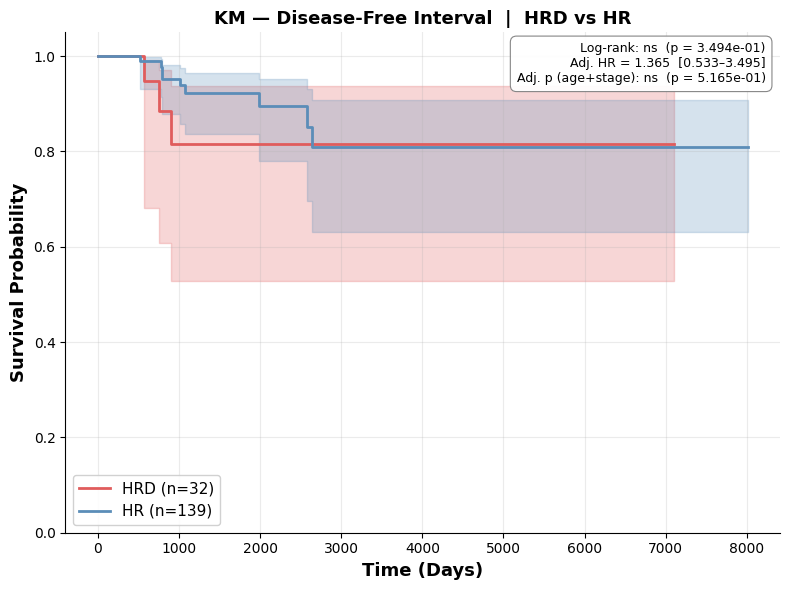

In [29]:
# ── Example calls for different endpoints ─────────────────────────────────────

results_os  = run_survival_analysis(
    test_preds, tcga_clinical,
    duration_col='OS.time',  event_col='OS',
    analysis_label='Overall Survival'
)

results_pfi = run_survival_analysis(
    test_preds, tcga_clinical,
    duration_col='PFI.time', event_col='PFI',
    analysis_label='Progression-Free Interval'
)

results_dfi = run_survival_analysis(
    test_preds, tcga_clinical,
    duration_col='DFI.time', event_col='DFI',
    analysis_label='Disease-Free Interval'
)

results_dfi = run_survival_analysis(
    test_preds, tcga_clinical,
    duration_col='DSS.time', event_col='DSS',
    analysis_label='Disease-Free Interval'
)

In [30]:
import warnings
import plotly.express as px
from scipy.stats import ttest_ind, mannwhitneyu, pearsonr
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning)
best_threshold = 0.7
# ── 1. Load & prep ISPY2 expression data ─────────────────────────────────────

ispy2_expr = pd.read_csv(
    'softHRD_val_data/GSE173839_ISPY2_AgilentGeneExp_durvaPlusCtr_FFPE_meanCol_geneLevel_n105.txt',
    sep='\t'
)
ispy2_expr.set_index('GeneName', inplace=True)
ispy2_expr_transposed = ispy2_expr.T
ispy2_expr_transposed.sort_index(inplace=True)
ispy2_expr_transposed.dropna(inplace=True)

# ── 2. Load & prep ISPY2 response data ───────────────────────────────────────

ispy2_response = pd.read_csv('softHRD_val_data/GSE173839_ISPY2_DurvalumabOlaparibArm_biomarkers.csv')
ispy2_response.loc[ispy2_response["pCR.status"] == -1, "pCR.status"] = 0
ispy2_response["ResearchID"] = ispy2_response["ResearchID"].astype(str).str.strip()
ispy2_response.sort_values(by='ResearchID', inplace=True)
ispy2_response.set_index('ResearchID', inplace=True)

# ── 3. Align samples ──────────────────────────────────────────────────────────

common_indices         = ispy2_expr_transposed.index.intersection(ispy2_response.index)
ispy2_expr_aligned     = ispy2_expr_transposed.loc[common_indices]
ispy2_response_aligned = ispy2_response.loc[common_indices].copy()
print(f"Aligned samples: {len(common_indices)}")

# ── 4. Match features to training set ────────────────────────────────────────

training_features = list(common_vae_genes.columns)
common_features   = [f for f in training_features if f in ispy2_expr_aligned.columns]
missing_features  = [f for f in training_features if f not in ispy2_expr_aligned.columns]

print(f"Training features : {len(training_features)}")
print(f"Matched           : {len(common_features)}")
print(f"Missing           : {len(missing_features)}  → filled with 0")

# Build validation matrix column-by-column (avoids shape/duplicate issues)
validation_subset = pd.DataFrame(0.0, index=ispy2_expr_aligned.index, columns=training_features)
for feat in common_features:
    validation_subset[feat] = ispy2_expr_aligned[feat].values

assert validation_subset.shape[1] == best_model.n_features_in_, \
    f"Shape mismatch: {validation_subset.shape[1]} vs {best_model.n_features_in_}"
print(f"✓ Validation matrix shape: {validation_subset.shape}")

# ── 5. Scale ──────────────────────────────────────────────────────────────────

val_scaler = StandardScaler()
val_scaled = val_scaler.fit_transform(validation_subset)

# ── 6. Predict ────────────────────────────────────────────────────────────────

pred_linear = best_model.predict(val_scaled)                        # continuous
pred_binary = (pred_linear >= best_threshold).astype(int)           # numpy array

# Safe mapping without .map()
ispy2_response_aligned['predictions_linear'] = pred_linear
ispy2_response_aligned['predictions_binary'] = pred_binary
ispy2_response_aligned['HRD_predicted']      = np.where(pred_binary == 1, 'HRD', 'HR')
ispy2_response_aligned['pCR_label']          = np.where(
    ispy2_response_aligned['pCR.status'] == 1, 'pCR', 'No pCR'
)

print(f"\nPredicted HRD : {pred_binary.sum()}  |  HR : {(pred_binary == 0).sum()}")
print(f"pCR           : {(ispy2_response_aligned['pCR.status']==1).sum()}  "
      f"|  No pCR : {(ispy2_response_aligned['pCR.status']==0).sum()}")

# ── 7. Statistical tests ──────────────────────────────────────────────────────

def run_stats(group0, group1, label0, label1, metric):
    t_stat, p_t = ttest_ind(group0, group1, equal_var=False)
    u_stat, p_u = mannwhitneyu(group0, group1, alternative='two-sided')
    print(f"\n  {metric}  —  {label0} vs {label1}")
    print(f"  Welch's t  : t = {t_stat:.4f},  p = {p_t:.4f}")
    print(f"  Mann-Whitney U : U = {u_stat:.4f},  p = {p_u:.4f}")
    return p_t, p_u

df = ispy2_response_aligned

print("\n" + "="*60)
print("STATISTICAL TESTS")
print("="*60)

df = df[df['predictions_linear'] <= 1]
run_stats(
    df.loc[df['pCR.status'] == 0, 'predictions_linear'],
    df.loc[df['pCR.status'] == 1, 'predictions_linear'],
    'No pCR', 'pCR', 'Linear HRD score ~ pCR'
)

run_stats(
    df.loc[df['predictions_binary'] == 0, 'PARPi7_sig.'],
    df.loc[df['predictions_binary'] == 1, 'PARPi7_sig.'],
    'HR', 'HRD', 'PARPi7 ~ predicted HRD'
)

run_stats(
    df.loc[(df['predictions_binary'] == 0) & (df['pCR.status'] == 0), 'PARPi7_sig.'],
    df.loc[(df['predictions_binary'] == 1) & (df['pCR.status'] == 1), 'PARPi7_sig.'],
    'HR & No pCR', 'HRD & pCR', 'PARPi7 ~ HRD+pCR concordance'
)

r_val, p_val = pearsonr(df['PARPi7_sig.'], df['predictions_linear'])
print(f"\n  Pearson r (linear score vs PARPi7) : r = {r_val:.4f},  p = {p_val:.4e}")

# ── 8. Plot 1 — Linear HRD score by predicted HRD status × pCR ───────────────

fig1 = px.box(
    df, x='HRD_predicted', y='predictions_linear', color='pCR_label',
    points='all',
    category_orders={'HRD_predicted': ['HR', 'HRD'], 'pCR_label': ['No pCR', 'pCR']},
    color_discrete_map={'pCR': '#E05C5C', 'No pCR': '#5B8DB8'},
    title='Predicted HRD Status × pCR — Linear HRD Regression Score',
    labels={
        'HRD_predicted':      'Predicted HRD Status',
        'predictions_linear': 'Linear HRD Score',
        'pCR_label':          'pCR Status'
    }
)
fig1.add_hline(
    y=best_threshold, line_dash='dash', line_color='black',
    annotation_text=f'Threshold = {best_threshold}',
    annotation_position='top right'
)
fig1.update_layout(
    font=dict(size=13), plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey'), boxmode='group'
)
fig1.show()

# ── Plot 2 — Linear HRD score vs PARPi7 (scatter + OLS) ──────────────────────

fig2 = px.scatter(
    df, x='PARPi7_sig.', y='predictions_linear',
    color='pCR_label', trendline='ols',
    color_discrete_map={'pCR': '#E05C5C', 'No pCR': '#5B8DB8'},
    title='Linear HRD Score vs PARPi7 Signal',
    labels={
        'PARPi7_sig.':        'PARPi7 Signal',
        'predictions_linear': 'Linear HRD Score',
        'pCR_label':          'pCR Status'
    }
)
fig2.add_annotation(
    x=df['PARPi7_sig.'].mean(), y=df['predictions_linear'].max(),
    text=f"Pearson r = {r_val:.3f}<br>p = {p_val:.2e}",
    showarrow=False, font=dict(size=13),
    bordercolor='black', borderwidth=1,
    borderpad=5, bgcolor='white', opacity=1.0
)
fig2.update_layout(
    font=dict(size=13), plot_bgcolor='white',
    xaxis=dict(gridcolor='lightgrey'), yaxis=dict(gridcolor='lightgrey')
)
fig2.show()

# ── Plot 3 — PARPi7 signal by predicted HRD × pCR ────────────────────────────

fig3 = px.box(
    df, x='HRD_predicted', y='PARPi7_sig.', color='pCR_label',
    points='all',
    category_orders={'HRD_predicted': ['HR', 'HRD'], 'pCR_label': ['No pCR', 'pCR']},
    color_discrete_map={'pCR': '#E05C5C', 'No pCR': '#5B8DB8'},
    title='PARPi7 Signal stratified by Predicted HRD Status × pCR',
    labels={
        'HRD_predicted': 'Predicted HRD Status',
        'PARPi7_sig.':   'PARPi7 Signal',
        'pCR_label':     'pCR Status'
    }
)
fig3.update_layout(
    font=dict(size=13), plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey'), boxmode='group'
)
fig3.show()

Aligned samples: 80
Training features : 1762
Matched           : 1674
Missing           : 88  → filled with 0
✓ Validation matrix shape: (80, 1762)

Predicted HRD : 12  |  HR : 68
pCR           : 28  |  No pCR : 52

STATISTICAL TESTS

  Linear HRD score ~ pCR  —  No pCR vs pCR
  Welch's t  : t = -3.8080,  p = 0.0003
  Mann-Whitney U : U = 385.0000,  p = 0.0011

  PARPi7 ~ predicted HRD  —  HR vs HRD
  Welch's t  : t = -2.4953,  p = 0.0266
  Mann-Whitney U : U = 218.0000,  p = 0.0277

  PARPi7 ~ HRD+pCR concordance  —  HR & No pCR vs HRD & pCR
  Welch's t  : t = -3.8173,  p = 0.0048
  Mann-Whitney U : U = 45.0000,  p = 0.0050

  Pearson r (linear score vs PARPi7) : r = 0.5595,  p = 8.3251e-08


Linear HRD score ~ pCR status
  Welch's t-test   : t = -3.9996, p = 0.0002
  Mann-Whitney U   : U = 385.0000, p = 0.0006

Pearson r (linear score vs PARPi7) : r = 0.5846, p = 1.2444e-08


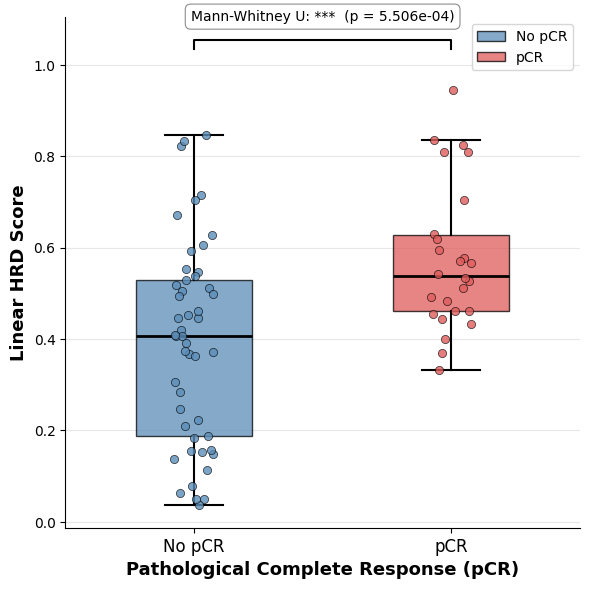

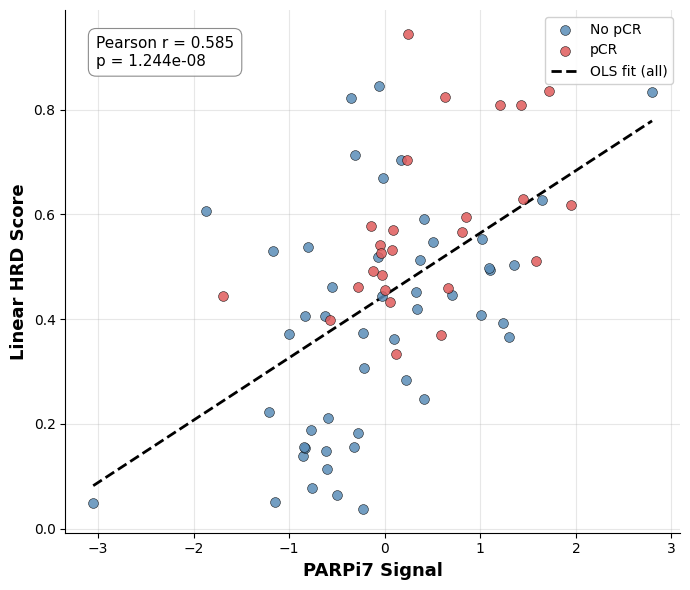

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind, mannwhitneyu, pearsonr
import numpy as np

df = ispy2_response_aligned

# ── Statistical tests ─────────────────────────────────────────────────────────

g0 = df.loc[df['pCR.status'] == 0, 'predictions_linear']
g1 = df.loc[df['pCR.status'] == 1, 'predictions_linear']
t_stat, p_t = ttest_ind(g0, g1, equal_var=False)
u_stat, p_u = mannwhitneyu(g0, g1, alternative='two-sided')

print("Linear HRD score ~ pCR status")
print(f"  Welch's t-test   : t = {t_stat:.4f}, p = {p_t:.4f}")
print(f"  Mann-Whitney U   : U = {u_stat:.4f}, p = {p_u:.4f}")

r_val, p_val = pearsonr(df['PARPi7_sig.'], df['predictions_linear'])
print(f"\nPearson r (linear score vs PARPi7) : r = {r_val:.4f}, p = {p_val:.4e}")

# ── Shared ────────────────────────────────────────────────────────────────────

color_map = {'No pCR': '#5B8DB8', 'pCR': '#E05C5C'}
order     = ['No pCR', 'pCR']

# ── Plot 1 — Boxplot: pCR status vs Linear HRD Score ─────────────────────────

fig, ax = plt.subplots(figsize=(6, 6))

df = df[(df['predictions_linear'] <= 1) & (df['predictions_linear'] >= 0)]
groups_data = {
    'No pCR': df.loc[df['pCR_label'] == 'No pCR', 'predictions_linear'],
    'pCR':    df.loc[df['pCR_label'] == 'pCR',    'predictions_linear'],
}

bp = ax.boxplot(
    [groups_data['No pCR'], groups_data['pCR']],
    positions=[0, 1], widths=0.45, patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=4, alpha=0.5),
    showfliers=False
)
for patch, label in zip(bp['boxes'], order):
    patch.set_facecolor(color_map[label])
    patch.set_alpha(0.75)

# Jittered points
np.random.seed(42)
for i, label in enumerate(order):
    vals   = groups_data[label]
    jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
    ax.scatter(i + jitter, vals, color=color_map[label],
               edgecolors='black', linewidths=0.5, s=35, zorder=3, alpha=0.8)

# Significance bracket + Mann-Whitney p value (full precision)

def p_label(p):
    if   p < 0.001: stars = '***'
    elif p < 0.01:  stars = '**'
    elif p < 0.05:  stars = '*'
    else:           stars = 'ns'
    return f"{stars}  (p = {p:.3e})"
    
y_max   = df['predictions_linear'].max()
y_range = df['predictions_linear'].max() - df['predictions_linear'].min()
y_bar   = y_max + y_range * 0.12
tip     = y_range * 0.02

ax.plot([0, 0, 1, 1],
        [y_bar - tip, y_bar, y_bar, y_bar - tip],
        color='black', linewidth=1.5)

ax.text(0.5, y_bar + y_range * 0.04,
        f"Mann-Whitney U: {p_label(p_u)}",
        ha='center', va='bottom', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='grey', linewidth=0.8, alpha=0.9))

# Legend patches
patches = [mpatches.Patch(facecolor=color_map[l], edgecolor='black',
                           alpha=0.75, label=l) for l in order]
ax.legend(handles=patches, fontsize=10)

ax.set_xticks([0, 1])
ax.set_xticklabels(order, fontsize=12)
ax.set_xlabel('Pathological Complete Response (pCR)',       fontsize=13, fontweight='bold')
ax.set_ylabel('Linear HRD Score', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Plot 2 — Scatter: PARPi7 signal vs Linear HRD Score ──────────────────────

fig, ax = plt.subplots(figsize=(7, 6))

for label, color in color_map.items():
    subset = df[df['pCR_label'] == label]
    ax.scatter(subset['PARPi7_sig.'], subset['predictions_linear'],
               color=color, edgecolors='black', linewidths=0.4,
               s=50, alpha=0.85, label=label, zorder=3)

# OLS trendline
m, b   = np.polyfit(df['PARPi7_sig.'], df['predictions_linear'], 1)
x_line = np.linspace(df['PARPi7_sig.'].min(), df['PARPi7_sig.'].max(), 200)
ax.plot(x_line, m * x_line + b, color='black', linewidth=2,
        linestyle='--', label='OLS fit (all)', zorder=2)

# Scatter Pearson annotation
ax.text(0.05, 0.95,
        f"Pearson r = {r_val:.3f}\np = {p_val:.3e}",
        transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor='grey', linewidth=0.8, alpha=0.9))

ax.set_xlabel('PARPi7 Signal',    fontsize=13, fontweight='bold')
ax.set_ylabel('Linear HRD Score', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Linear HRD score ~ pCR status
  Welch's t-test : t = -3.9996, p = 0.0002
  Mann-Whitney U : U = 385.0000, p = 0.0006

Pearson r (linear score vs PARPi7) : r = 0.5846, p = 1.2444e-08


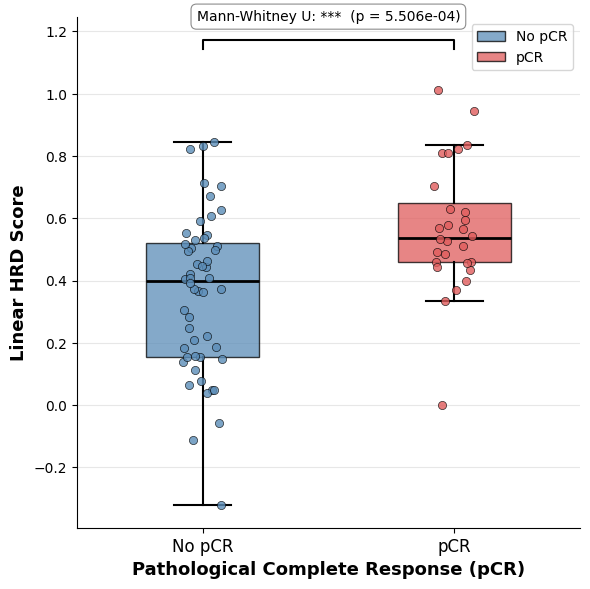

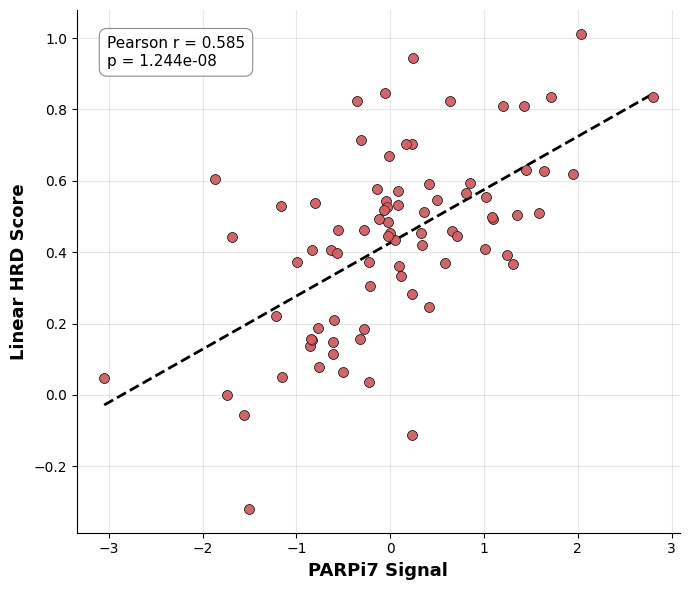

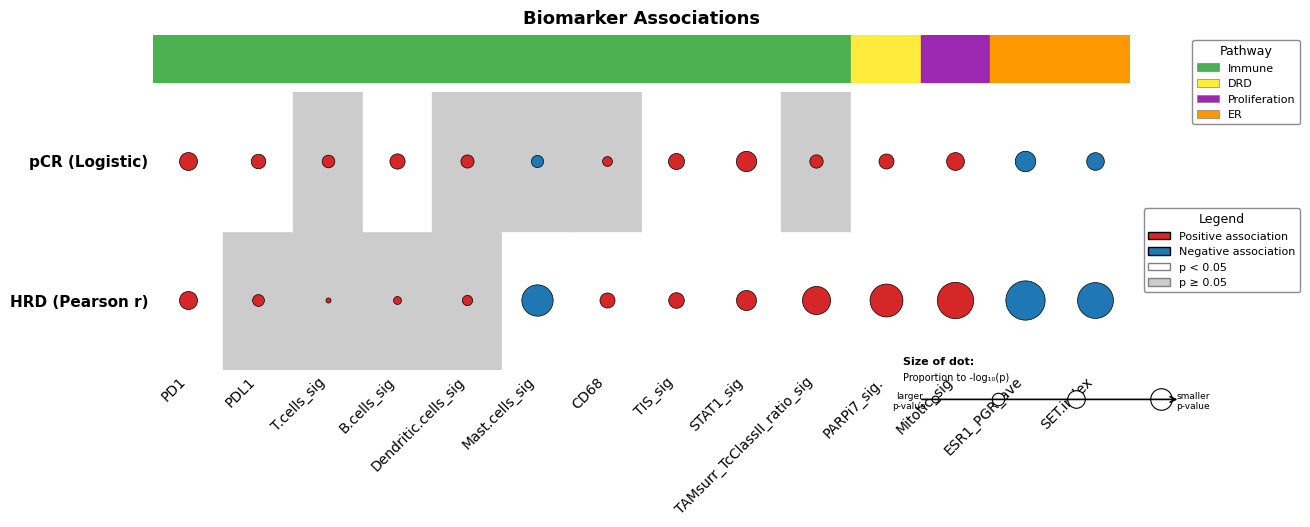


All figures saved to: /tscc/lustre/restricted/alexandrov-ddn/users/ymadakamutil/DeepHRD_full/ImmuneHRD_data/softHRD_figs


In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
from scipy.stats import mannwhitneyu, ttest_ind, pearsonr, spearmanr
from scipy.special import expit
from sklearn.linear_model import LogisticRegression, LinearRegression
from scipy.stats import norm
import os
import warnings
warnings.filterwarnings('ignore')

def analyze_hrd(df, out_dir='softHRD_figs'):
    """
    Analyzes HRD predictions against pCR status and biomarker signatures.
    
    Plots:
        1. Boxplot: Linear HRD Score by pCR status
        2. Scatter: PARPi7 signal vs Linear HRD Score
        3. Dot plot: pCR (logistic) + HRD (Pearson r) across all biomarkers
    """

    # ── Output directory ───────────────────────────────────────────────────────
    os.makedirs(out_dir, exist_ok=True)

    # ── Setup ──────────────────────────────────────────────────────────────────
    df = df.copy()
    df['pCR_label'] = df['pCR.status'].map({0: 'No pCR', 1: 'pCR'})
    df_filtered = df#[(df['predictions_linear'] >= 0) & (df['predictions_linear'] <= 1)].copy()

    biomarker_cols = [
        col for col in df.iloc[:, 4:20].columns.tolist()
        if col not in ('pCR.status', 'predictions_linear')
    ]
    color_map = {'No pCR': '#5B8DB8', 'pCR': '#E05C5C'}
    order = ['No pCR', 'pCR']

    # ── Statistical tests ──────────────────────────────────────────────────────
    g0 = df.loc[df['pCR.status'] == 0, 'predictions_linear']
    g1 = df.loc[df['pCR.status'] == 1, 'predictions_linear']
    t_stat, p_t = ttest_ind(g0, g1, equal_var=False)
    u_stat, p_u = mannwhitneyu(g0, g1, alternative='two-sided')

    print("Linear HRD score ~ pCR status")
    print(f"  Welch's t-test : t = {t_stat:.4f}, p = {p_t:.4f}")
    print(f"  Mann-Whitney U : U = {u_stat:.4f}, p = {p_u:.4f}")

    r_val, p_val = pearsonr(df_filtered['PARPi7_sig.'], df_filtered['predictions_linear'])
    print(f"\nPearson r (linear score vs PARPi7) : r = {r_val:.4f}, p = {p_val:.4e}")

    # ── Helper ─────────────────────────────────────────────────────────────────
    def p_label(p):
        if   p < 0.001: stars = '***'
        elif p < 0.01:  stars = '**'
        elif p < 0.05:  stars = '*'
        else:           stars = 'ns'
        return f"{stars}  (p = {p:.3e})"

    # ── Plot 1 — Boxplot ───────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 6))

    groups_data = {
        'No pCR': df_filtered.loc[df_filtered['pCR_label'] == 'No pCR', 'predictions_linear'],
        'pCR':    df_filtered.loc[df_filtered['pCR_label'] == 'pCR',    'predictions_linear'],
    }

    bp = ax.boxplot(
        [groups_data['No pCR'], groups_data['pCR']],
        positions=[0, 1], widths=0.45, patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=4, alpha=0.5),
        showfliers=False
    )
    for patch, label in zip(bp['boxes'], order):
        patch.set_facecolor(color_map[label])
        patch.set_alpha(0.75)

    np.random.seed(42)
    for i, label in enumerate(order):
        vals   = groups_data[label]
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(i + jitter, vals, color=color_map[label],
                   edgecolors='black', linewidths=0.5, s=35, zorder=3, alpha=0.8)

    y_max   = df_filtered['predictions_linear'].max()
    y_range = df_filtered['predictions_linear'].max() - df_filtered['predictions_linear'].min()
    y_bar   = y_max + y_range * 0.12
    tip     = y_range * 0.02

    ax.plot([0, 0, 1, 1], [y_bar - tip, y_bar, y_bar, y_bar - tip],
            color='black', linewidth=1.5)
    ax.text(0.5, y_bar + y_range * 0.04,
            f"Mann-Whitney U: {p_label(p_u)}",
            ha='center', va='bottom', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='grey', linewidth=0.8, alpha=0.9))

    patches_leg = [mpatches.Patch(facecolor=color_map[l], edgecolor='black',
                                   alpha=0.75, label=l) for l in order]
    ax.legend(handles=patches_leg, fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(order, fontsize=12)
    ax.set_xlabel('Pathological Complete Response (pCR)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Linear HRD Score', fontsize=13, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, 'fig1_boxplot_pCR_vs_HRD.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # ── Plot 2 — Scatter: PARPi7 vs HRD ───────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 6))

    for label, color in color_map.items():
        subset = df_filtered#[df_filtered['pCR_label'] == label]
        ax.scatter(subset['PARPi7_sig.'], subset['predictions_linear'],
                   color=color, edgecolors='black', linewidths=0.4,
                   s=50, alpha=0.85, label=label, zorder=3)

    m, b   = np.polyfit(df_filtered['PARPi7_sig.'], df_filtered['predictions_linear'], 1)
    x_line = np.linspace(df_filtered['PARPi7_sig.'].min(), df_filtered['PARPi7_sig.'].max(), 200)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=2,
            linestyle='--', label='OLS fit (all)', zorder=2)

    ax.text(0.05, 0.95, f"Pearson r = {r_val:.3f}\np = {p_val:.3e}",
            transform=ax.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='grey', linewidth=0.8, alpha=0.9))

    ax.set_xlabel('PARPi7 Signal',    fontsize=13, fontweight='bold')
    ax.set_ylabel('Linear HRD Score', fontsize=13, fontweight='bold')
    #ax.legend(fontsize=10, framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, 'fig2_scatter_PARPi7_vs_HRD.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # ── Plot 3 — Dot plot ──────────────────────────────────────────────────────
    pathway_map = {
        'PD1':                         ('Immune',        '#4CAF50'),
        'PDL1':                        ('Immune',        '#4CAF50'),
        'T.cells_sig':                 ('Immune',        '#4CAF50'),
        'B.cells_sig':                 ('Immune',        '#4CAF50'),
        'Dendritic.cells_sig':         ('Immune',        '#4CAF50'),
        'Mast.cells_sig':              ('Immune',        '#4CAF50'),
        'CD68':                        ('Immune',        '#4CAF50'),
        'TIS_sig':                     ('Immune',        '#4CAF50'),
        'STAT1_sig':                   ('Immune',        '#4CAF50'),
        'TAMsurr_TcClassII_ratio_sig': ('Immune',        '#4CAF50'),
        'PARPi7_sig.':                 ('DRD',           '#FFEB3B'),
        'Mitotic_sig':                 ('Proliferation', '#9C27B0'),
        'ESR1_PGR_ave':                ('ER',            '#FF9800'),
        'SET.index':                   ('ER',            '#FF9800'),
    }

    rows = {
        'HRD (Pearson r)':  {'stats': [], 'sig': []},
        'pCR (Logistic)':   {'stats': [], 'sig': []},
    }

    df_clean = df.dropna(subset=biomarker_cols + ['pCR.status', 'predictions_linear'])

    for col in biomarker_cols:
        x = df_clean[col].values

        # Row 1: logistic regression — Wald test p-value
        lr = LogisticRegression(max_iter=1000)
        lr.fit(x.reshape(-1, 1), df_clean['pCR.status'].values)
        coef = lr.coef_[0][0]
        pred_prob = lr.predict_proba(x.reshape(-1, 1))[:, 1]
        W = np.diag(pred_prob * (1 - pred_prob))
        X_mat = np.column_stack([np.ones(len(x)), x])
        cov = np.linalg.pinv(X_mat.T @ W @ X_mat)
        se = np.sqrt(cov[1, 1])
        z = coef / se
        p_logistic = 2 * (1 - norm.cdf(abs(z)))
        rows['pCR (Logistic)']['stats'].append(coef)
        rows['pCR (Logistic)']['sig'].append(p_logistic)

        # Row 2: Pearson correlation
        r, p_r = spearmanr(x, df_clean['predictions_linear'].values)
        rows['HRD (Pearson r)']['stats'].append(r)
        rows['HRD (Pearson r)']['sig'].append(p_r)

    row_labels = list(rows.keys())
    n_bio      = len(biomarker_cols)
    n_rows     = len(row_labels)
    bar_height = 0.35

    fig, axes = plt.subplots(
        2, 1,
        figsize=(max(12, n_bio * 0.9), 4 + bar_height),
        gridspec_kw={'height_ratios': [bar_height, n_rows], 'hspace': 0.05}
    )
    ax_bar, ax = axes

    # Pathway color bar
    for col_idx, col in enumerate(biomarker_cols):
        _, color = pathway_map.get(col, ('Unknown', '#BBBBBB'))
        ax_bar.add_patch(plt.Rectangle(
            (col_idx - 0.5, 0), 1, 1, color=color, zorder=1
        ))
    ax_bar.set_xlim(-0.5, n_bio - 0.5)
    ax_bar.set_ylim(0, 1)
    ax_bar.axis('off')

    seen = {}
    for col in biomarker_cols:
        name, color = pathway_map.get(col, ('Unknown', '#BBBBBB'))
        if name not in seen:
            seen[name] = color
    pathway_patches = [
        mpatches.Patch(facecolor=c, edgecolor='grey', linewidth=0.5, label=n)
        for n, c in seen.items()
    ]
    ax_bar.legend(handles=pathway_patches, loc='upper right',
                  bbox_to_anchor=(1.18, 1.0), fontsize=8,
                  title='Pathway', title_fontsize=9,
                  framealpha=0.9, edgecolor='grey')
    ax_bar.set_title('Biomarker Associations', fontsize=13,
                     fontweight='bold', pad=8)

    # Dots
    max_neg_log_p = max(
        max(-np.log10(np.clip(rows[r]['sig'], 1e-10, 1))) for r in row_labels
    )
    dot_scale = 800 / max_neg_log_p

    for row_idx, row_name in enumerate(row_labels):
        stats = rows[row_name]['stats']
        sigs  = rows[row_name]['sig']
        for col_idx, (stat, p) in enumerate(zip(stats, sigs)):
            color = '#D62728' if stat > 0 else '#1F77B4'
            size  = -np.log10(max(p, 1e-10)) * dot_scale
            bg    = 'white' if p < 0.05 else '#CCCCCC'
            ax.add_patch(plt.Rectangle(
                (col_idx - 0.5, row_idx - 0.5), 1, 1,
                color=bg, zorder=0
            ))
            ax.scatter(col_idx, row_idx, s=size, color=color,
                       edgecolors='black', linewidths=0.5, zorder=2)

    ax.set_xlim(-0.5, n_bio - 0.5)
    ax.set_ylim(-0.5, n_rows - 0.5)
    ax.set_xticks(range(n_bio))
    ax.set_xticklabels(biomarker_cols, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, fontsize=11, fontweight='bold')

    # Color/background legend
    from matplotlib.lines import Line2D
    legend_elements = [
        mpatches.Patch(facecolor='#D62728', edgecolor='black',
                       label='Positive association'),
        mpatches.Patch(facecolor='#1F77B4', edgecolor='black',
                       label='Negative association'),
        mpatches.Patch(facecolor='white',   edgecolor='grey',
                       label='p < 0.05'),
        mpatches.Patch(facecolor='#CCCCCC', edgecolor='grey',
                       label='p ≥ 0.05'),
    ]
    ax.legend(handles=legend_elements, loc='upper right',
              bbox_to_anchor=(1.18, 0.6), fontsize=8,
              title='Legend', title_fontsize=9,
              framealpha=0.9, edgecolor='grey')

    ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
    ax.tick_params(length=0)

    # Size legend inset
    ax_size = fig.add_axes([0.72, 0.02, 0.25, 0.12])
    ax_size.axis('off')
    ax_size.text(0.0, 0.85, 'Size of dot:', fontsize=8, fontweight='bold',
                 transform=ax_size.transAxes)
    ax_size.text(0.0, 0.55, 'Proportion to -log\u2081\u2080(p)',
                 fontsize=7, transform=ax_size.transAxes)

    p_values    = [0.5, 0.1, 0.01, 0.001]
    x_positions = [0.10, 0.30, 0.55, 0.82]
    y_pos       = 0.18
    for x_pos, p in zip(x_positions, p_values):
        size = -np.log10(max(p, 1e-10)) * dot_scale
        ax_size.scatter(x_pos, y_pos, s=size, color='white',
                        edgecolors='black', linewidths=0.8,
                        transform=ax_size.transAxes, zorder=2, clip_on=False)
    ax_size.annotate('', xy=(0.88, y_pos), xytext=(0.05, y_pos),
                     xycoords='axes fraction', textcoords='axes fraction',
                     arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
    ax_size.text(0.02, 0.0, 'larger\np-value', fontsize=6.5,
                 ha='center', transform=ax_size.transAxes)
    ax_size.text(0.92, 0.0, 'smaller\np-value', fontsize=6.5,
                 ha='center', transform=ax_size.transAxes)

    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, 'fig3_dotplot_biomarker_associations.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nAll figures saved to: {os.path.abspath(out_dir)}")


# ── Run ────────────────────────────────────────────────────────────────────────
analyze_hrd(ispy2_response_aligned)

Linear HRD score ~ pCR status
  Welch's t-test : t = -3.9996, p = 0.0002
  Mann-Whitney U : U = 385.0000, p = 0.0006

Pearson r (linear score vs PARPi7) : r = 0.5846, p = 1.2444e-08


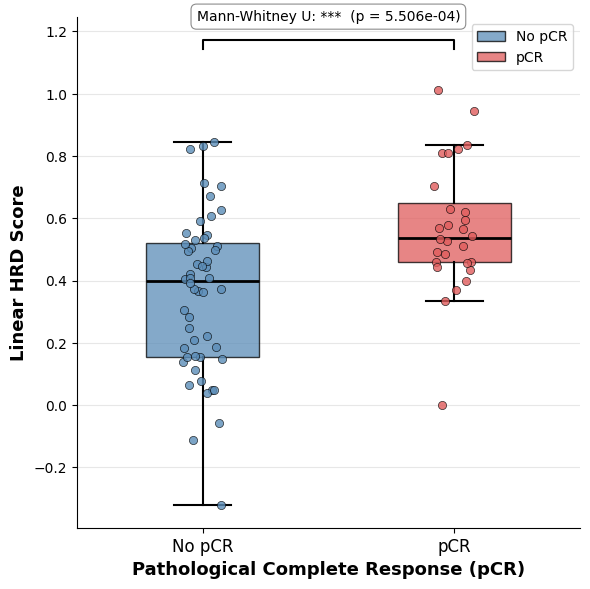

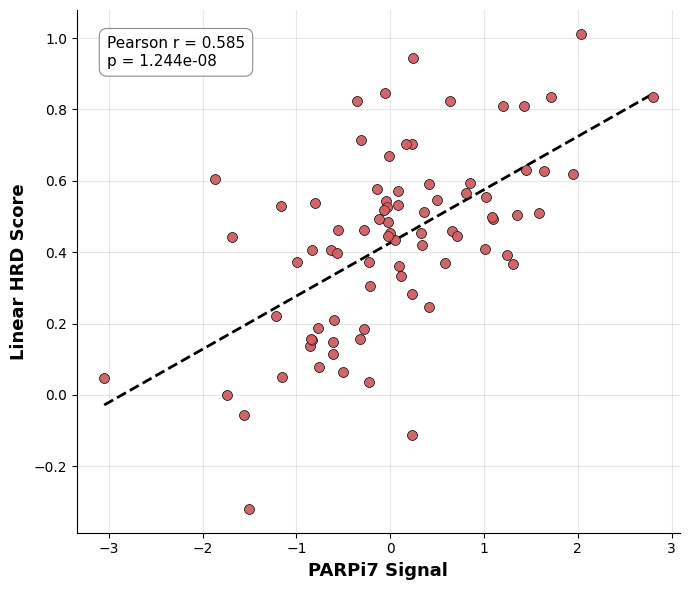

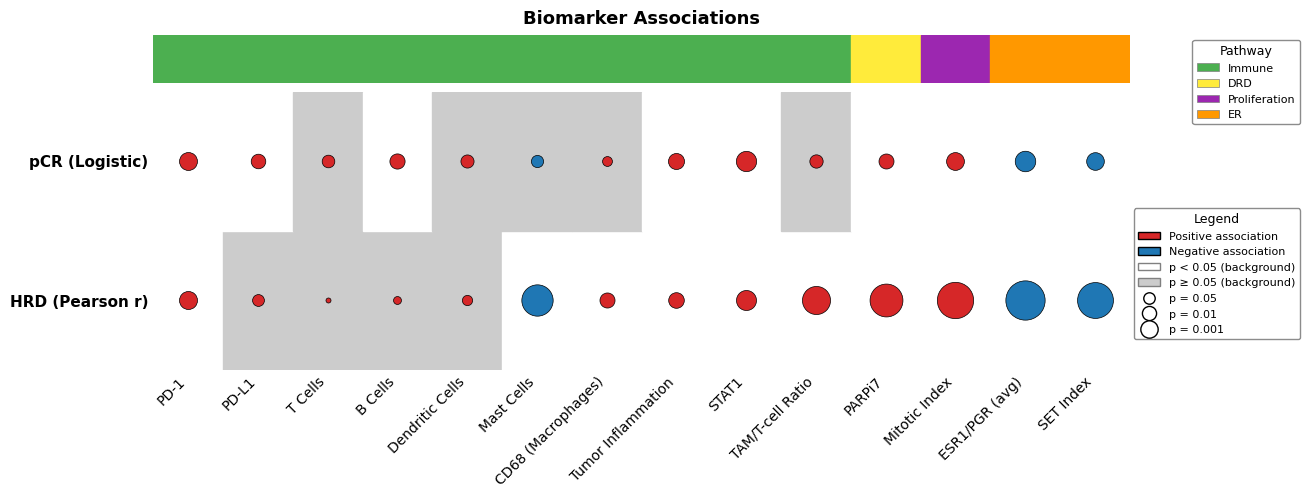


All figures saved to: /tscc/lustre/restricted/alexandrov-ddn/users/ymadakamutil/DeepHRD_full/ImmuneHRD_data/softHRD_figs


In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
from scipy.stats import mannwhitneyu, ttest_ind, pearsonr, spearmanr
from scipy.special import expit
from sklearn.linear_model import LogisticRegression, LinearRegression
from scipy.stats import norm
import os
import warnings
warnings.filterwarnings('ignore')

def analyze_hrd(df, out_dir='softHRD_figs'):
    os.makedirs(out_dir, exist_ok=True)

    df = df.copy()
    df['pCR_label'] = df['pCR.status'].map({0: 'No pCR', 1: 'pCR'})
    df_filtered = df

    biomarker_cols = [
        col for col in df.iloc[:, 4:20].columns.tolist()
        if col not in ('pCR.status', 'predictions_linear')
    ]
    color_map = {'No pCR': '#5B8DB8', 'pCR': '#E05C5C'}
    order = ['No pCR', 'pCR']

    g0 = df.loc[df['pCR.status'] == 0, 'predictions_linear']
    g1 = df.loc[df['pCR.status'] == 1, 'predictions_linear']
    t_stat, p_t = ttest_ind(g0, g1, equal_var=False)
    u_stat, p_u = mannwhitneyu(g0, g1, alternative='two-sided')

    print("Linear HRD score ~ pCR status")
    print(f"  Welch's t-test : t = {t_stat:.4f}, p = {p_t:.4f}")
    print(f"  Mann-Whitney U : U = {u_stat:.4f}, p = {p_u:.4f}")

    r_val, p_val = pearsonr(df_filtered['PARPi7_sig.'], df_filtered['predictions_linear'])
    print(f"\nPearson r (linear score vs PARPi7) : r = {r_val:.4f}, p = {p_val:.4e}")

    def p_label(p):
        if   p < 0.001: stars = '***'
        elif p < 0.01:  stars = '**'
        elif p < 0.05:  stars = '*'
        else:           stars = 'ns'
        return f"{stars}  (p = {p:.3e})"

    # ── Plot 1 — Boxplot ───────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 6))
    groups_data = {
        'No pCR': df_filtered.loc[df_filtered['pCR_label'] == 'No pCR', 'predictions_linear'],
        'pCR':    df_filtered.loc[df_filtered['pCR_label'] == 'pCR',    'predictions_linear'],
    }
    bp = ax.boxplot(
        [groups_data['No pCR'], groups_data['pCR']],
        positions=[0, 1], widths=0.45, patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=4, alpha=0.5),
        showfliers=False
    )
    for patch, label in zip(bp['boxes'], order):
        patch.set_facecolor(color_map[label])
        patch.set_alpha(0.75)

    np.random.seed(42)
    for i, label in enumerate(order):
        vals   = groups_data[label]
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        ax.scatter(i + jitter, vals, color=color_map[label],
                   edgecolors='black', linewidths=0.5, s=35, zorder=3, alpha=0.8)

    y_max   = df_filtered['predictions_linear'].max()
    y_range = df_filtered['predictions_linear'].max() - df_filtered['predictions_linear'].min()
    y_bar   = y_max + y_range * 0.12
    tip     = y_range * 0.02

    ax.plot([0, 0, 1, 1], [y_bar - tip, y_bar, y_bar, y_bar - tip], color='black', linewidth=1.5)
    ax.text(0.5, y_bar + y_range * 0.04,
            f"Mann-Whitney U: {p_label(p_u)}",
            ha='center', va='bottom', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='grey', linewidth=0.8, alpha=0.9))

    patches_leg = [mpatches.Patch(facecolor=color_map[l], edgecolor='black', alpha=0.75, label=l) for l in order]
    ax.legend(handles=patches_leg, fontsize=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(order, fontsize=12)
    ax.set_xlabel('Pathological Complete Response (pCR)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Linear HRD Score', fontsize=13, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, 'fig1_boxplot_pCR_vs_HRD.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # ── Plot 2 — Scatter ───────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 6))
    for label, color in color_map.items():
        subset = df_filtered
        ax.scatter(subset['PARPi7_sig.'], subset['predictions_linear'],
                   color=color, edgecolors='black', linewidths=0.4,
                   s=50, alpha=0.85, label=label, zorder=3)

    m, b   = np.polyfit(df_filtered['PARPi7_sig.'], df_filtered['predictions_linear'], 1)
    x_line = np.linspace(df_filtered['PARPi7_sig.'].min(), df_filtered['PARPi7_sig.'].max(), 200)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=2, linestyle='--', label='OLS fit (all)', zorder=2)
    ax.text(0.05, 0.95, f"Pearson r = {r_val:.3f}\np = {p_val:.3e}",
            transform=ax.transAxes, fontsize=11, va='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='grey', linewidth=0.8, alpha=0.9))
    ax.set_xlabel('PARPi7 Signal',    fontsize=13, fontweight='bold')
    ax.set_ylabel('Linear HRD Score', fontsize=13, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, 'fig2_scatter_PARPi7_vs_HRD.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # ── Plot 3 — Dot plot ──────────────────────────────────────────────────────
    pathway_map = {
        'PD1':                         ('Immune',        '#4CAF50'),
        'PDL1':                        ('Immune',        '#4CAF50'),
        'T.cells_sig':                 ('Immune',        '#4CAF50'),
        'B.cells_sig':                 ('Immune',        '#4CAF50'),
        'Dendritic.cells_sig':         ('Immune',        '#4CAF50'),
        'Mast.cells_sig':              ('Immune',        '#4CAF50'),
        'CD68':                        ('Immune',        '#4CAF50'),
        'TIS_sig':                     ('Immune',        '#4CAF50'),
        'STAT1_sig':                   ('Immune',        '#4CAF50'),
        'TAMsurr_TcClassII_ratio_sig': ('Immune',        '#4CAF50'),
        'PARPi7_sig.':                 ('DRD',           '#FFEB3B'),
        'Mitotic_sig':                 ('Proliferation', '#9C27B0'),
        'ESR1_PGR_ave':                ('ER',            '#FF9800'),
        'SET.index':                   ('ER',            '#FF9800'),
    }

    # Human-readable x-axis labels
    label_map = {
        'PD1':                         'PD-1',
        'PDL1':                        'PD-L1',
        'T.cells_sig':                 'T Cells',
        'B.cells_sig':                 'B Cells',
        'Dendritic.cells_sig':         'Dendritic Cells',
        'Mast.cells_sig':              'Mast Cells',
        'CD68':                        'CD68 (Macrophages)',
        'TIS_sig':                     'Tumor Inflammation',
        'STAT1_sig':                   'STAT1',
        'TAMsurr_TcClassII_ratio_sig': 'TAM/T-cell Ratio',
        'PARPi7_sig.':                 'PARPi7',
        'Mitotic_sig':                 'Mitotic Index',
        'ESR1_PGR_ave':                'ESR1/PGR (avg)',
        'SET.index':                   'SET Index',
    }

    rows = {
        'HRD (Pearson r)':  {'stats': [], 'sig': []},
        'pCR (Logistic)':   {'stats': [], 'sig': []},
    }

    df_clean = df.dropna(subset=biomarker_cols + ['pCR.status', 'predictions_linear'])

    for col in biomarker_cols:
        x = df_clean[col].values

        lr = LogisticRegression(max_iter=1000)
        lr.fit(x.reshape(-1, 1), df_clean['pCR.status'].values)
        coef = lr.coef_[0][0]
        pred_prob = lr.predict_proba(x.reshape(-1, 1))[:, 1]
        W = np.diag(pred_prob * (1 - pred_prob))
        X_mat = np.column_stack([np.ones(len(x)), x])
        cov = np.linalg.pinv(X_mat.T @ W @ X_mat)
        se = np.sqrt(cov[1, 1])
        z = coef / se
        p_logistic = 2 * (1 - norm.cdf(abs(z)))
        rows['pCR (Logistic)']['stats'].append(coef)
        rows['pCR (Logistic)']['sig'].append(p_logistic)

        r, p_r = spearmanr(x, df_clean['predictions_linear'].values)
        rows['HRD (Pearson r)']['stats'].append(r)
        rows['HRD (Pearson r)']['sig'].append(p_r)

    row_labels = list(rows.keys())
    n_bio      = len(biomarker_cols)
    n_rows     = len(row_labels)
    bar_height = 0.35

    fig, axes = plt.subplots(
        2, 1,
        figsize=(max(12, n_bio * 0.9), 4 + bar_height),
        gridspec_kw={'height_ratios': [bar_height, n_rows], 'hspace': 0.05}
    )
    ax_bar, ax = axes

    for col_idx, col in enumerate(biomarker_cols):
        _, color = pathway_map.get(col, ('Unknown', '#BBBBBB'))
        ax_bar.add_patch(plt.Rectangle((col_idx - 0.5, 0), 1, 1, color=color, zorder=1))
    ax_bar.set_xlim(-0.5, n_bio - 0.5)
    ax_bar.set_ylim(0, 1)
    ax_bar.axis('off')

    seen = {}
    for col in biomarker_cols:
        name, color = pathway_map.get(col, ('Unknown', '#BBBBBB'))
        if name not in seen:
            seen[name] = color
    pathway_patches = [
        mpatches.Patch(facecolor=c, edgecolor='grey', linewidth=0.5, label=n)
        for n, c in seen.items()
    ]
    ax_bar.legend(handles=pathway_patches, loc='upper right',
                  bbox_to_anchor=(1.18, 1.0), fontsize=8,
                  title='Pathway', title_fontsize=9,
                  framealpha=0.9, edgecolor='grey')
    ax_bar.set_title('Biomarker Associations', fontsize=13, fontweight='bold', pad=8)

    max_neg_log_p = max(
        max(-np.log10(np.clip(rows[r]['sig'], 1e-10, 1))) for r in row_labels
    )
    dot_scale = 800 / max_neg_log_p

    for row_idx, row_name in enumerate(row_labels):
        stats = rows[row_name]['stats']
        sigs  = rows[row_name]['sig']
        for col_idx, (stat, p) in enumerate(zip(stats, sigs)):
            color = '#D62728' if stat > 0 else '#1F77B4'
            size  = -np.log10(max(p, 1e-10)) * dot_scale
            bg    = 'white' if p < 0.05 else '#CCCCCC'
            ax.add_patch(plt.Rectangle(
                (col_idx - 0.5, row_idx - 0.5), 1, 1, color=bg, zorder=0
            ))
            ax.scatter(col_idx, row_idx, s=size, color=color,
                       edgecolors='black', linewidths=0.5, zorder=2)

    ax.set_xlim(-0.5, n_bio - 0.5)
    ax.set_ylim(-0.5, n_rows - 0.5)
    ax.set_xticks(range(n_bio))

    # ── Human-readable x-axis labels ──────────────────────────────────────────
    readable_labels = [label_map.get(col, col) for col in biomarker_cols]
    ax.set_xticklabels(readable_labels, rotation=45, ha='right', fontsize=10)

    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, fontsize=11, fontweight='bold')

    from matplotlib.lines import Line2D

    legend_elements = [
        mpatches.Patch(facecolor='#D62728', edgecolor='black', label='Positive association'),
        mpatches.Patch(facecolor='#1F77B4', edgecolor='black', label='Negative association'),
        mpatches.Patch(facecolor='white',   edgecolor='grey',  label='p < 0.05 (background)'),
        mpatches.Patch(facecolor='#CCCCCC', edgecolor='grey',  label='p ≥ 0.05 (background)'),
        #Line2D([0], [0], linestyle='none', label='── dot size ──'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
               markeredgecolor='black',
               markersize=np.sqrt(-np.log10(0.05)  * dot_scale * 0.65),
               label='p = 0.05',  linestyle='none'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
               markeredgecolor='black',
               markersize=np.sqrt(-np.log10(0.01)  * dot_scale * 0.65),
               label='p = 0.01',  linestyle='none'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
               markeredgecolor='black',
               markersize=np.sqrt(-np.log10(0.001) * dot_scale * 0.65),
               label='p = 0.001', linestyle='none'),
    ]
    ax.legend(handles=legend_elements, loc='upper right',
              bbox_to_anchor=(1.18, 0.6), fontsize=8,
              title='Legend', title_fontsize=9,
              framealpha=0.9, edgecolor='grey')

    ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
    ax.tick_params(length=0)

    # ── ax_size block removed entirely ────────────────────────────────────────

    plt.tight_layout()
    fig.savefig(os.path.join(out_dir, 'fig3_dotplot_biomarker_associations.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f"\nAll figures saved to: {os.path.abspath(out_dir)}")


analyze_hrd(ispy2_response_aligned)